In [320]:
%load_ext autoreload
%autoreload 2 --print

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [321]:

from cmap import Colormap
from datetime import datetime
from mplutil import util as vu
import matplotlib.pyplot as plt
from pathlib import Path
from typing import TypedDict

import tqdm
import numpy as np
from numpy import linalg as la
import os
import joblib as jl
import time
import seaborn as sns

In [322]:
from dynrn.viz import styles
from dynrn.viz.styles import getc
t20 = lambda x: getc(f"seaborn:tab20{x}")
colors, plotter = styles.init_plt(
    Path('../plots/notebook/diffdiff-pft').resolve(),
    fmt = 'pdf', display=False)
plot_root = Path(plotter.plot_dir)

### Basic hashed together model

In [ ]:
# GPe https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9987574/

In [158]:
def pathway_euler(
    sd,
    si,
    dt=5,  # µs
    Dp=2e-1,  # mV
    Fp=-42,  # mV
    Rp=-60,  # mV
    tau_sp=10,  # µs
    syn_sp=5e-1,  # mV / µs
    Dn=9e-2,  # mV
    Fn=-42,  # mV
    Rn=-60,  # mV
    tau_pn=10,  # µs
    syn_pn=2e-1,  # mV / µs
    tau_sn=10,  # µs
    syn_sn=2e-1,  # mV / µs
):
    T = len(sd)

    # Voltage/spike histories and initial conditions
    ipsp_sp = np.zeros((T,))
    Vp = np.zeros((T,))
    sp = np.zeros((T,))
    ipsp_pn = np.zeros((T,))
    ipsp_sn = np.zeros((T,))
    Vn = np.zeros((T,))
    pn = np.zeros((T,))
    Vp[0] = Rp
    Vn[0] = Rn

    for t in range(T - 1):
        # striatopallidal IPSP
        decay = np.exp(-np.log(2) / (tau_sp / dt))
        ipsp_sp[t + 1] = decay * ipsp_sp[t] + syn_sp * si[t]

        # integration and spiking of pallidal neuron
        if Vp[t] >= Fp:
            Vp[t + 1] = Rp
            sp[t + 1] = 1
        else:
            Vp[t + 1] = Vp[t] + Dp * dt - ipsp_sp[t + 1] * dt

        # pallidonigral and striatonigral IPSP
        decay = np.exp(-np.log(2) / (tau_pn / dt))
        ipsp_pn[t + 1] = decay * ipsp_pn[t] + syn_pn * sp[t]
        decay = np.exp(-np.log(2) / (tau_sn / dt))
        ipsp_sn[t + 1] = decay * ipsp_sn[t] + syn_sn * sd[t]

        # integration and spiking of nigral neuron
        if Vn[t] >= Fn:
            Vn[t + 1] = Rn
            pn[t + 1] = 1
        else:
            Vn[t + 1] = Vn[t] + (Dn - ipsp_pn[t + 1] - ipsp_sn[t + 1]) * dt

    return (ipsp_sp, Vp, sp, ipsp_pn, ipsp_sn, Vn, pn)

si = np.zeros((300,))
sd = np.zeros((300,))
si[140] = 1
sd[140] = 1
Dp = 2e-1
Fp = -42
Dn = 9e-2
Fn = -42
dt = 5
ipsp_sp, Vp, sp, ipsp_pn, ipsp_sn, Vn, pn = pathway_euler(sd, si)

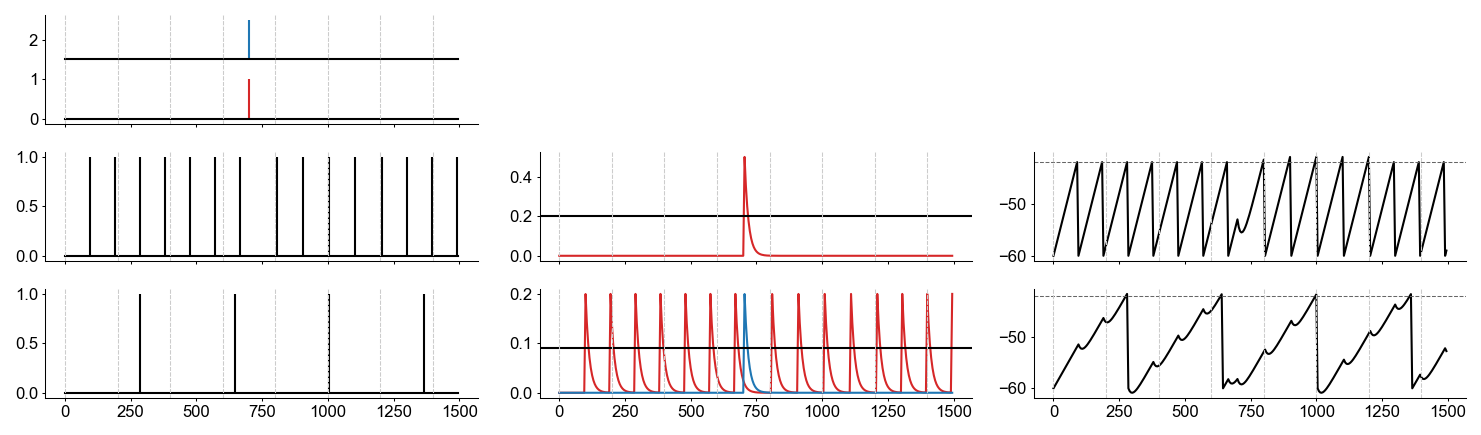

In [159]:
fig, ax = plt.subplots(3, 3, figsize=(10, 3), dpi=150, sharex=True)
x = np.arange(0, dt * len(sd), dt)
ax[0, 0].stem(x, si, linefmt='C3-', markerfmt='', basefmt='k-')
ax[0, 0].stem(x, sd + 1.5, linefmt='C0-', markerfmt='', basefmt='k-', bottom = 1.5)
ax[0, 1].set_visible(False)
ax[0, 2].set_visible(False)
# pallidal neuron
ax[1, 1].plot(x, ipsp_sp, color = 'C3')
ax[1, 1].axhline(Dp, color='k', ls='-', label='Dp')
ax[1, 2].plot(x, Vp, color = 'k')
ax[1, 2].axhline(Fp, color='.4', ls='--', lw = 0.5, label='Fp')
ax[1, 0].stem(x, sp, linefmt='k-', markerfmt='', basefmt='k-')
# nigral neuron
ax[2, 1].plot(x, ipsp_pn, color = 'C3')
ax[2, 1].plot(x, ipsp_sn, color = 'C0')
ax[2, 1].axhline(Dn, color='k', ls='-', label='Dn')
ax[2, 2].plot(x, Vn, color = 'k')
ax[2, 2].axhline(Fn, color='.4', ls='--', lw = 0.5, label='Fn')
ax[2, 0].stem(x, pn, linefmt='k-', markerfmt='', basefmt='k-')
for i in np.arange(0, len(sd), 40):
    for a in ax.ravel():
        a.axvline(i * dt, color='.8', ls='--', lw=0.5)
        a.axvline(i * dt, color='.8', ls='--', lw=0.5)
plotter.finalize(fig, None)

In [187]:
sd = np.zeros((1500,))
si = np.zeros((1500,))
sd[150:400:50] = 1
si[800:1050:50] = 1
Dp = 2e-2
Fp = -42
Dn = 1.5e-2
syn_sn = 2e-2
syn_sp = 2e-2
syn_pn = 2e-2
tau_sn = 100
tau_sp = 100
tau_pn = 100
Fn = -42
dt = 10
ipsp_sp, Vp, sp, ipsp_pn, ipsp_sn, Vn, pn = pathway_euler(
    sd,
    si,
    dt=dt,
    Dp=Dp,
    Fp=Fp,
    Dn=Dn,
    Fn=Fn,
    syn_sn=syn_sn,
    syn_sp=syn_sp,
    syn_pn=syn_pn,
    tau_sn=tau_sn,
    tau_sp=tau_sp,
    tau_pn=tau_pn,
)

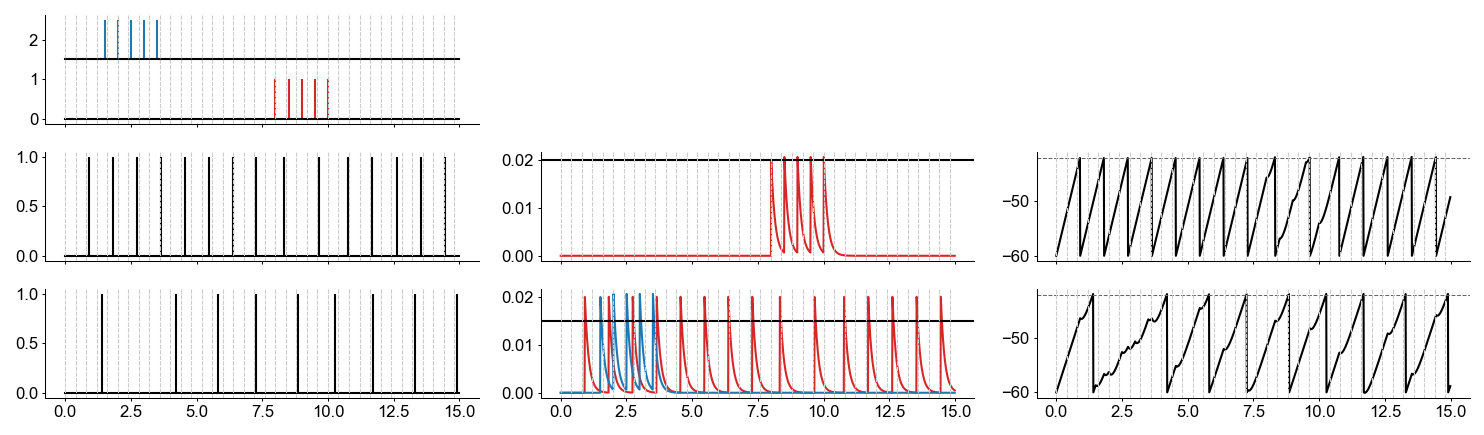

In [188]:
fig, ax = plt.subplots(3, 3, figsize=(10, 3), dpi=150, sharex=True)
x = np.arange(0, dt * len(sd) / 1000, dt / 1000)
ax[0, 0].stem(x, si, linefmt='C3-', markerfmt='', basefmt='k-')
ax[0, 0].stem(x, sd + 1.5, linefmt='C0-', markerfmt='', basefmt='k-', bottom = 1.5)
ax[0, 1].set_visible(False)
ax[0, 2].set_visible(False)
# pallidal neuron
ax[1, 1].plot(x, ipsp_sp, color = 'C3')
ax[1, 1].axhline(Dp, color='k', ls='-', label='Dp')
ax[1, 2].plot(x, Vp, color = 'k')
ax[1, 2].axhline(Fp, color='.4', ls='--', lw = 0.5, label='Fp')
ax[1, 0].stem(x, sp, linefmt='k-', markerfmt='', basefmt='k-')
# nigral neuron
ax[2, 1].plot(x, ipsp_pn, color = 'C3')
ax[2, 1].plot(x, ipsp_sn, color = 'C0')
ax[2, 1].axhline(Dn, color='k', ls='-', label='Dn')
ax[2, 2].plot(x, Vn, color = 'k')
ax[2, 2].axhline(Fn, color='.4', ls='--', lw = 0.5, label='Fn')
ax[2, 0].stem(x, pn, linefmt='k-', markerfmt='', basefmt='k-')
for i in np.arange(0, len(sd), 40):
    for a in ax.ravel():
        a.axvline(i * dt / 1000, color='.8', ls='--', lw=0.5)
        a.axvline(i * dt / 1000, color='.8', ls='--', lw=0.5)
plotter.finalize(fig, None)

In [189]:
sd = np.zeros((1500,))
si = np.zeros((1500,))
sd[150:400:50] = 1
si[150:400:50] = 1
Dp = 2e-2
Fp = -42
Dn = 1.5e-2
syn_sn = 2e-2
syn_sp = 2e-2
syn_pn = 2e-2
tau_sn = 100
tau_sp = 100
tau_pn = 100
Fn = -42
dt = 10
ipsp_sp, Vp, sp, ipsp_pn, ipsp_sn, Vn, pn = pathway_euler(
    sd,
    si,
    dt=dt,
    Dp=Dp,
    Fp=Fp,
    Dn=Dn,
    Fn=Fn,
    syn_sn=syn_sn,
    syn_sp=syn_sp,
    syn_pn=syn_pn,
    tau_sn=tau_sn,
    tau_sp=tau_sp,
    tau_pn=tau_pn,
)

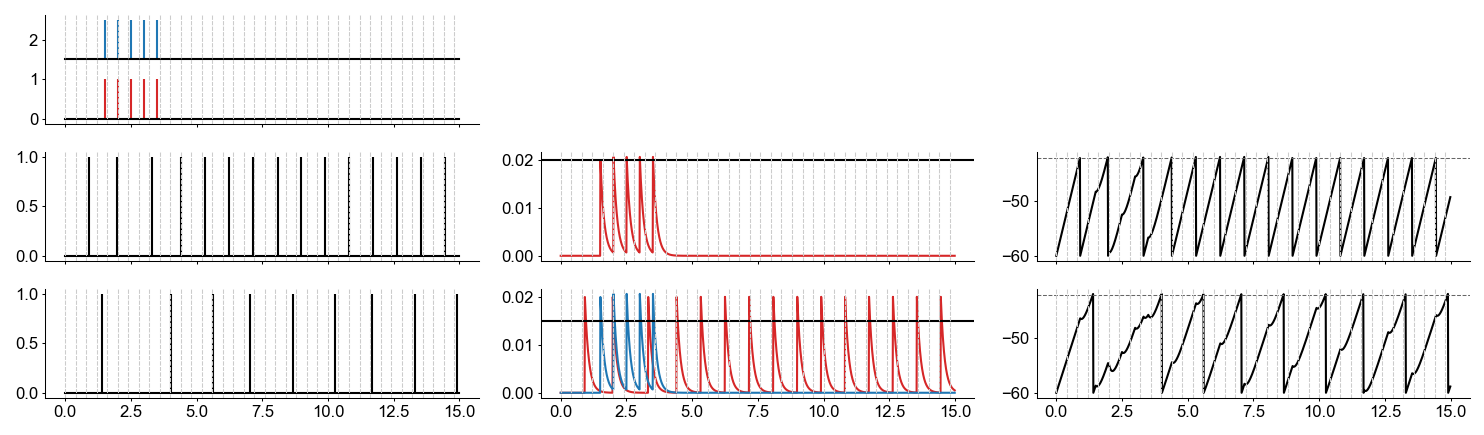

In [190]:
fig, ax = plt.subplots(3, 3, figsize=(10, 3), dpi=150, sharex=True)
x = np.arange(0, dt * len(sd) / 1000, dt / 1000)
ax[0, 0].stem(x, si, linefmt='C3-', markerfmt='', basefmt='k-')
ax[0, 0].stem(x, sd + 1.5, linefmt='C0-', markerfmt='', basefmt='k-', bottom = 1.5)
ax[0, 1].set_visible(False)
ax[0, 2].set_visible(False)
# pallidal neuron
ax[1, 1].plot(x, ipsp_sp, color = 'C3')
ax[1, 1].axhline(Dp, color='k', ls='-', label='Dp')
ax[1, 2].plot(x, Vp, color = 'k')
ax[1, 2].axhline(Fp, color='.4', ls='--', lw = 0.5, label='Fp')
ax[1, 0].stem(x, sp, linefmt='k-', markerfmt='', basefmt='k-')
# nigral neuron
ax[2, 1].plot(x, ipsp_pn, color = 'C3')
ax[2, 1].plot(x, ipsp_sn, color = 'C0')
ax[2, 1].axhline(Dn, color='k', ls='-', label='Dn')
ax[2, 2].plot(x, Vn, color = 'k')
ax[2, 2].axhline(Fn, color='.4', ls='--', lw = 0.5, label='Fn')
ax[2, 0].stem(x, pn, linefmt='k-', markerfmt='', basefmt='k-')
for i in np.arange(0, len(sd), 40):
    for a in ax.ravel():
        a.axvline(i * dt / 1000, color='.8', ls='--', lw=0.5)
        a.axvline(i * dt / 1000, color='.8', ls='--', lw=0.5)
plotter.finalize(fig, None)

In [ ]:
# Don't have enough spikes to think about this as a derivative
# If many units then perhaps we have enough spikes for a decrease in 
# IPSP at beginning of volley and increase at end
# How are multiple derivatives merged if multiple striatal units
# converging?

### Simulation framework

In [736]:
class Population(TypedDict):
    N: int
    drive: np.ndarray  # (N,), mV / µs
    threshold: float  # mV
    reset: float  # mV
    drift: float  # mV / µs


class Synapse(TypedDict):
    tau: float  # µs
    peak: np.ndarray  # (N_target, N_source), mV / µs
    sign: int
    source: str
    target: str


class PopulationHistory(TypedDict):
    V: np.ndarray  # mV, (T, N)
    spikes: np.ndarray  # (T, N) in [0, 1]


class SynapseHistory(TypedDict):
    psc: np.ndarray  # mV / , (T, N_target)


class SpikingNetwork:
    def __init__(
        self,
        populations: dict[str, Population],
        synapses: dict[str, Synapse],
    ):
        self.populations = populations
        self.synapses = synapses

    def simulate(self, dt: float, seed=0, **control_trains: dict[str, np.ndarray]):
        
        rng = np.random.default_rng(seed)

        # Create history object spikes according to `control_trains`
        nt = next(iter(control_trains.values())).shape[-2]
        hist = SpikeHistory.zeros(self.populations, self.synapses, nt)
        for k, spikes in control_trains.items():
            if spikes.shape != hist.populations[k]["spikes"].shape:
                raise ValueError(
                    f"Got control train of shape {spikes.shape} for"
                    f"{k} but expected {hist.populations[k]['spikes'].shape}"
                )
            hist.populations[k]["spikes"] = spikes

        # Calculate network state at step t+1 given state at step t
        # for each population in topological order
        for step in range(nt - 1):
            for pop in self.populations:
                if pop in control_trains:
                    continue
                self._simulate_population(pop, hist, step, dt, rng)

        return hist

    def _simulate_population(
        self, pop: str, hist: "SpikeHistory", step: int, dt: float, rng: np.random.Generator
    ):  

        # --- Calculate postsynaptic currents from inputs and sum
        I = []
        for syn_name, syn in self.synapses.items():
            if syn["target"] != pop:
                continue
            psc = hist[syn_name]["psc"]
            source_spikes = hist.populations[syn["source"]]["spikes"]
            decay = np.exp(-np.log(2) / (syn["tau"] / dt))

            # (N_target,) = () @ (N_target,) + (N_target, N_source) @ (N_source,)
            psc[step + 1] = decay * psc[step] + syn["peak"] @ source_spikes[step]

            I.append(syn["sign"] * psc[step + 1])

        I = self.populations[pop]["drive"] + np.sum(I, axis=0)
        I += rng.normal(0, self.populations[pop]["drift"], I.shape)

        # --- Integrate currents and spike if threshold is reached
        V = hist.populations[pop]["V"]
        spikes = hist.populations[pop]["spikes"]
        spikes[step + 1] = V[step] >= self.populations[pop]["threshold"]
        
        V[step + 1] = np.where(
            spikes[step + 1], self.populations[pop]["reset"], V[step] + (I * dt)
        )


class SpikeHistory:
    def __init__(
        self,
        populations: dict[str, PopulationHistory],
        synapses: dict[str, SynapseHistory],
    ):
        self.populations = populations
        self.synapses = synapses

    def __getitem__(self, key):
        if isinstance(key, slice):
            return SpikeHistory(
                {
                    k: {"spikes": v["spikes"][key], "V": v["V"][key]}
                    for k, v in self.populations.items()
                },
                {
                    k: {"psc": v['psc'][key]}
                    for k, v in self.synapses.items()
                },
            )
        if key in self.populations and key in self.synapses:
            raise ValueError(f"Key {key} is ambiguous.")
        return self.populations[key] if key in self.populations else self.synapses[key]

    def __len__(self):
        return next(iter(self.populations.values()))["V"].shape[-2]

    @staticmethod
    def zeros(populations: dict[str, Population], synapses: dict[str, Synapse], t):
        return SpikeHistory(
            {
                k: {
                    "V": np.full((t, pop["N"]), pop["reset"], dtype="float"),
                    "spikes": np.zeros((t, pop["N"])),
                }
                for k, pop in populations.items()
            },
            {
                k: {"psc": np.zeros((t, populations[syn["target"]]["N"]))}
                for k, syn in synapses.items()
            },
        )

    def plot_units(self, net, dt, syn_colors=None, fig_kws={}):
        n_units = sum([pop["N"] for pop in net.populations.values()])
        fig, ax = plt.subplots(
            n_units, 3, figsize=(15, n_units), sharex=True, **fig_kws
        )

        nt = len(self)
        x = np.arange(0, dt * nt / 1000, dt / 1000)  # ms
        row = 0
        for i, (k, pop) in enumerate(self.populations.items()):
            for u in range(net.populations[k]["N"]):

                ax[row, 0].stem(
                    x, pop["spikes"][:, u], linefmt="k-", markerfmt="", basefmt="k-"
                )
                ax[row, 1].plot(x, pop["V"][:, u], color="k")
                ax[row, 1].axhline(
                    net.populations[k]["threshold"],
                    color=".4",
                    ls="--",
                    lw=0.5,
                    label="Threshold",
                )
                for j, (syn_name, syn) in enumerate(self.synapses.items()):
                    if net.synapses[syn_name]["target"] != k:
                        continue
                    ax[row, 2].plot(
                        x,
                        self.synapses[syn_name]["psc"][:, u],
                        color=syn_colors[syn_name],
                        label=syn_name,
                    )
                ax[row, 2].axhline(
                    net.populations[k]["drive"],
                    color="k",
                    ls="-",
                    lw=0.5,
                    label="Drive",
                )
                ax[row, 0].set_ylabel(f"{k}[{u}]")

                row += 1

        # gridlines
        for i in np.linspace(0, dt * nt / 1000, 7):
            for a in ax.ravel():
                a.axvline(i, color=".8", ls="--", lw=0.5, zorder=-2)
                a.axvline(i, color=".8", ls="--", lw=0.5, zorder=-2)

        return fig, ax

    def plot_populations(self, net, dt, syn_colors=None, fig_kws={}, rate_window=10):
        n_pop = len(net.populations)
        fig, ax = plt.subplots(n_pop, 3, figsize=(15, n_pop), sharex=True, **fig_kws)

        nt = len(self)
        x = np.arange(0, dt * nt / 1000, dt / 1000)  # ms
        rate_steps = max(int(1000 * rate_window / dt), 2)
        for i, (k, pop) in enumerate(self.populations.items()):
            ax[i, 0].scatter(*_raster_scatter(x, pop["spikes"]), s=1, color="k")

            rate_windows = np.lib.stride_tricks.sliding_window_view(
                pop["spikes"], rate_steps, axis=-2
            )
            rates = rate_windows.sum(axis=-1) / rate_window
            ax[i, 1].plot(x[rate_steps-1:], rates, color=".7", lw = 0.5)
            ax[i, 1].plot(x[rate_steps-1:], rates.mean(axis=-1), color="k", lw = 1)
            ax[i, 0].set_ylabel(k if i > 0 else f"Spikes\n{k}")
            ax[0, 1].set_ylabel("Rate [spikes/ms]")

        # gridlines
        for i in np.linspace(0, dt * len(x) / 1000, 7):
            for a in ax.ravel():
                a.axvline(i, color=".8", ls="--", lw=0.5, zorder=-2)
                a.axvline(i, color=".8", ls="--", lw=0.5, zorder=-2)

        return fig, ax


def _raster_scatter(x, spikes):
    x_spikes = np.concatenate([x[s == 1] for s in spikes.T])
    y_spikes = np.concatenate(
        [np.full([np.count_nonzero(s)], i) for i, s in enumerate(spikes.T)]
    )
    return x_spikes, y_spikes

#### Test / example

In [764]:
sd = np.zeros((2000, 1))
si = np.zeros((2000, 1))
sd[400:1200:50] = 1
si[400:1200:50] = 1

pops = dict(
    sd = dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    si = dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    p = dict(N=1, drive=2e-2, threshold=-42, reset=-60, drift=0),
    n = dict(N=1, drive=1.5e-2, threshold=-42, reset=-60, drift=0),
)
syns = dict(
    sdn = dict(tau=100, peak=np.array([[2e-2]]), sign=-1, source='sd', target='n'),
    sip = dict(tau=100, peak=np.array([[2e-2]]), sign=-1, source='si', target='p'),
    pn = dict(tau=100, peak=np.array([[2e-2]]), sign=-1, source='p', target='n'),
)
net = SpikingNetwork(pops, syns)
hist = net.simulate(dt, sd=sd, si=si)

/Users/kaifox/projects/loop/dynrn/plots/notebook/diffdiff-pft/simulation-framework.pdf


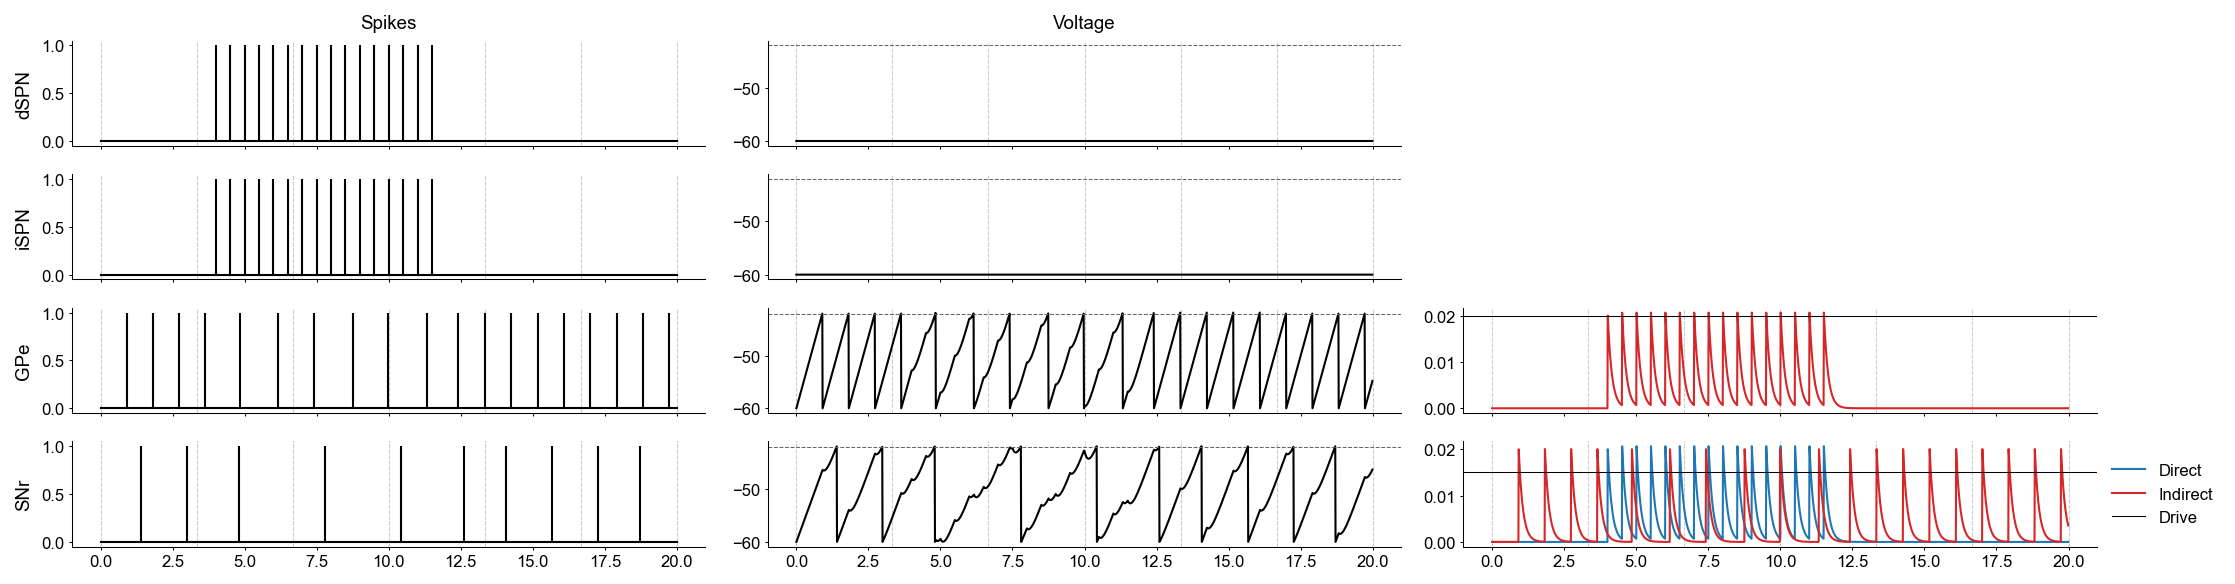

In [769]:
fig, ax = hist.plot_units(net, dt, syn_colors={'sdn': 'C0', 'sip': 'C3', 'pn': 'C3'}, fig_kws=dict(dpi=150))
ax[0, 0].set_title("Spikes", fontsize=9)
ax[0, 1].set_title("Voltage", fontsize=9)
ax[0, 2].set_title("Postsynaptic currents (absolute)", fontsize=9)
ax[0, 0].set_ylabel("dSPN", fontsize=9)
ax[1, 0].set_ylabel("iSPN", fontsize=9)
ax[2, 0].set_ylabel("GPe", fontsize=9)
ax[3, 0].set_ylabel("SNr", fontsize=9)
ax[0, 2].set_visible(False)
ax[1, 2].set_visible(False)
h, l = ax[3, 2].get_legend_handles_labels()
l = [{'sdn': 'Direct', 'pn': 'Indirect'}.get(L, L) for L in l]
vu.legend(ax[3, 2], (h, l))
plotter.finalize(fig, 'simulation-framework')

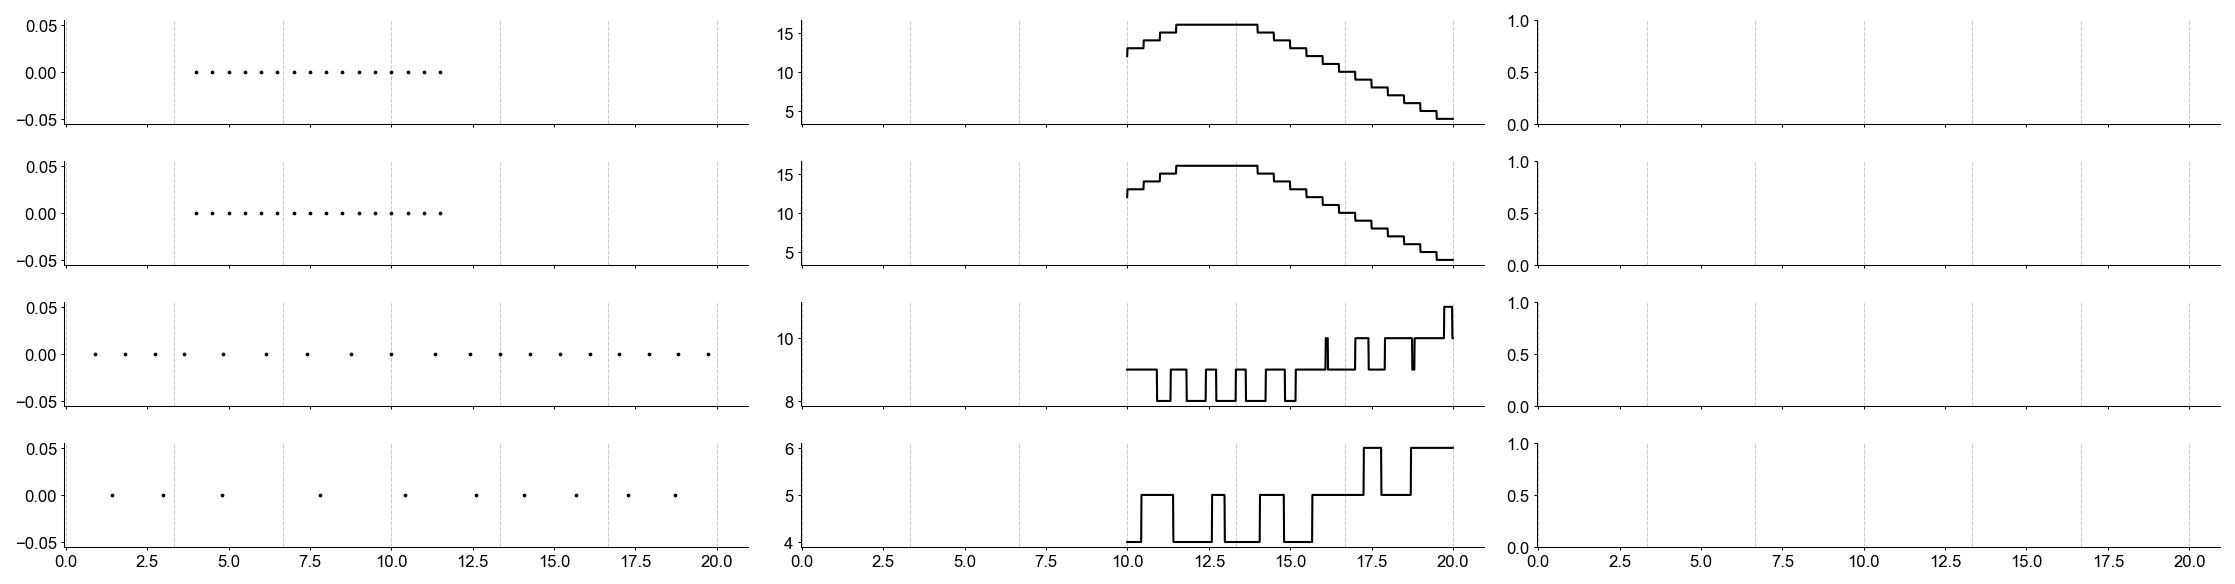

In [255]:
fig, ax = hist.plot_populations(net, dt, syn_colors={'sdn': 'C0', 'sip': 'C3', 'pn': 'C3'}, fig_kws=dict(dpi=150))
plotter.finalize(fig, None)

### Multi-unit populations

In [760]:
sd = np.zeros((5000, 1))
si = np.zeros((5000, 1))
sd[2400:3200:50] = 1
si[2400:3200:50] = 1

pops = dict(
    sd=dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    si=dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    p=dict(N=8, drive=np.array([2e-2] * 8), threshold=-42, reset=-60, drift=6e-2),
    n=dict(N=20, drive=np.array([2.5e-2] * 20), threshold=-42, reset=-60, drift=5e-2),
)
syns = dict(
    sdn=dict(tau=100, peak=np.array([[2e-2]] * 20), sign=-1, source="sd", target="n"),
    sip=dict(tau=100, peak=np.array([[4e-2]] * 8), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[0.9e-2] * 8] * 20), sign=-1, source="p", target="n"),
)
net = SpikingNetwork(pops, syns)
hist = net.simulate(dt, sd=sd, si=si, seed=0)[1000:]

Multi-unit populations


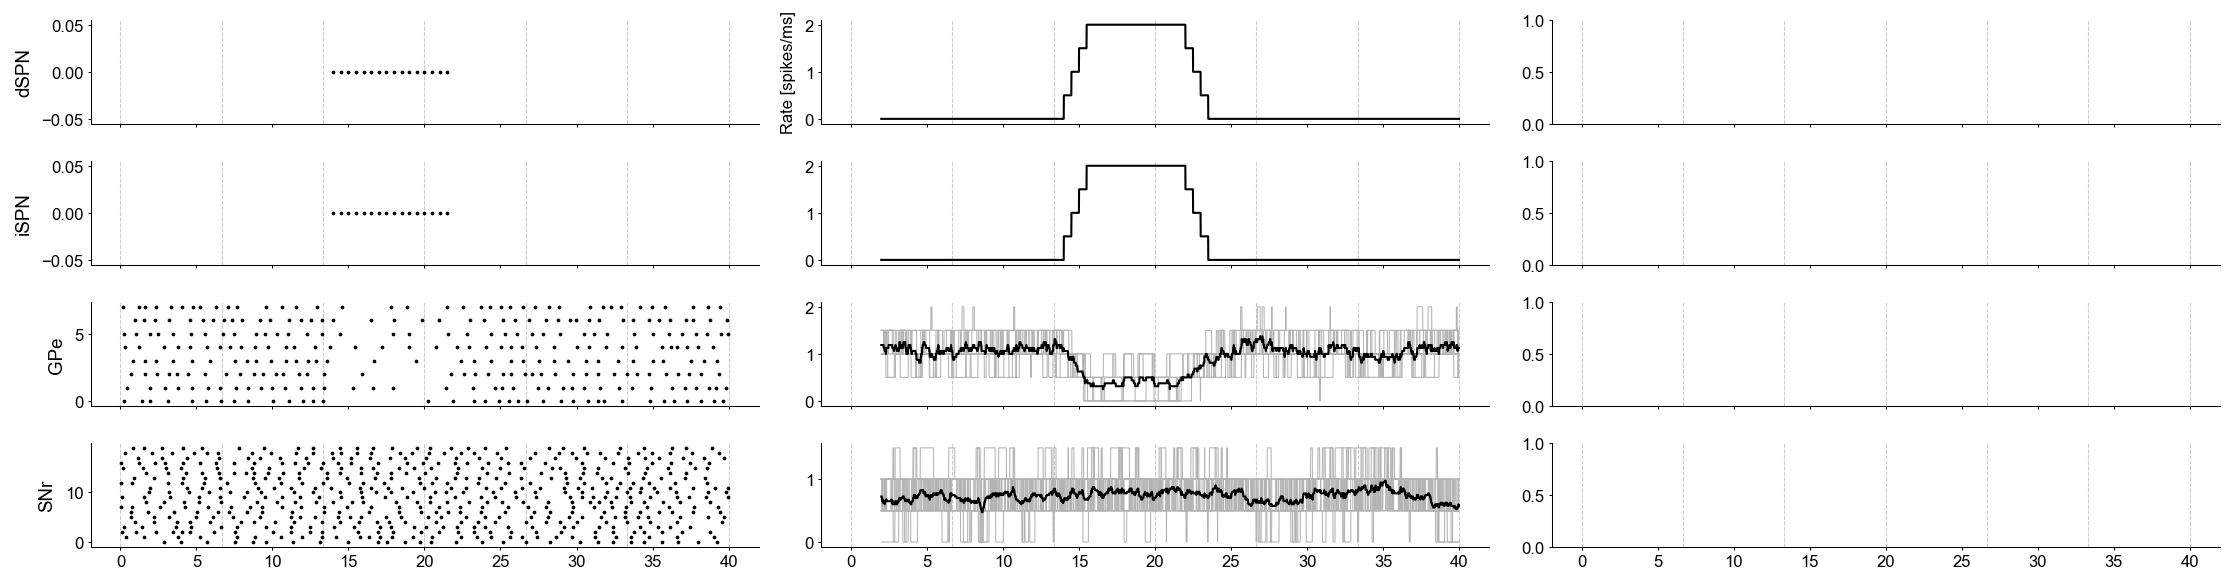

In [762]:
print("Multi-unit populations")
fig, ax = hist.plot_populations(net, dt, syn_colors={'sdn': 'C0', 'sip': 'C3', 'pn': 'C3'}, fig_kws=dict(dpi=150), rate_window=2)
ax[0, 0].set_ylabel("dSPN", fontsize=8)
ax[1, 0].set_ylabel("iSPN", fontsize=8)
ax[2, 0].set_ylabel("GPe", fontsize=8)
ax[3, 0].set_ylabel("SNr", fontsize=8)
plotter.finalize(fig, 'single-spn-')

In [771]:
# --- Strong pallidonigral connection, less noise
sd = np.zeros((5000, 1))
si = np.zeros((5000, 1))
sd[2400:3200:50] = 1
si[2400:3200:50] = 1

pops = dict(
    sd=dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    si=dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    p=dict(N=8, drive=np.array([2e-2] * 8), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=20, drive=np.array([2.5e-2] * 20), threshold=-42, reset=-60, drift=3e-2),
)
syns = dict(
    sdn=dict(tau=100, peak=np.array([[2e-2]] * 20), sign=-1, source="sd", target="n"),
    sip=dict(tau=100, peak=np.array([[6e-2]] * 8), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[0.7e-2] * 8] * 20), sign=-1, source="p", target="n"),
)
net = SpikingNetwork(pops, syns)
hist = net.simulate(dt, sd=sd, si=si, seed=0)[1000:]

Strong pallidonigral connection, less noise
/Users/kaifox/projects/loop/dynrn/plots/notebook/diffdiff-pft/simulation-populations-rates.pdf


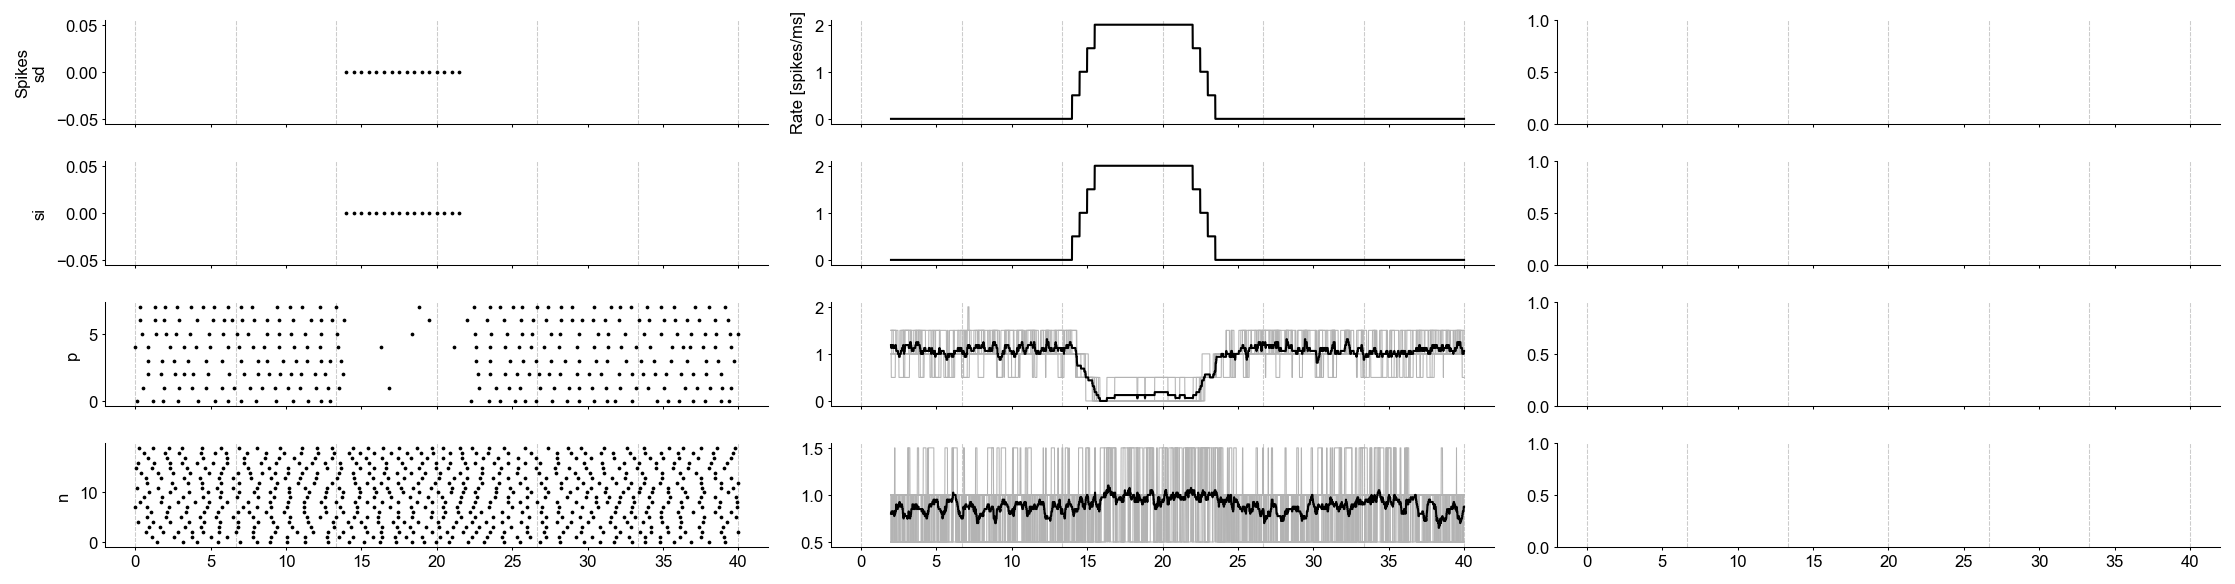

In [772]:
print("Strong pallidonigral connection, less noise")
fig, ax = hist.plot_populations(net, dt, syn_colors={'sdn': 'C0', 'sip': 'C3', 'pn': 'C3'}, fig_kws=dict(dpi=150), rate_window=2)
plotter.finalize(fig, 'simulation-populations-rates')

In [335]:
# --- Ramping SPNs
sd = np.zeros((5000, 1))
si = np.zeros((5000, 1))
tspn = np.cumsum(np.arange(70, 30, -2))
sd[2400 + tspn] = 1
si[2400 + tspn] = 1
Np = 8
Nn = 20

pops = dict(
    sd=dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    si=dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    p=dict(N=Np, drive=np.array([2e-2] * Np), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=20, drive=np.array([2.5e-2] * Nn), threshold=-42, reset=-60, drift=3e-2),
)
syns = dict(
    sdn=dict(tau=100, peak=np.array([[2e-2]] * Nn), sign=-1, source="sd", target="n"),
    sip=dict(tau=100, peak=np.array([[6e-2]] * Np), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[0.7e-2] * Np] * Nn), sign=-1, source="p", target="n"),
)
net = SpikingNetwork(pops, syns)
hist = net.simulate(dt, sd=sd, si=si, seed=0)[1000:]

Ramping SPNs


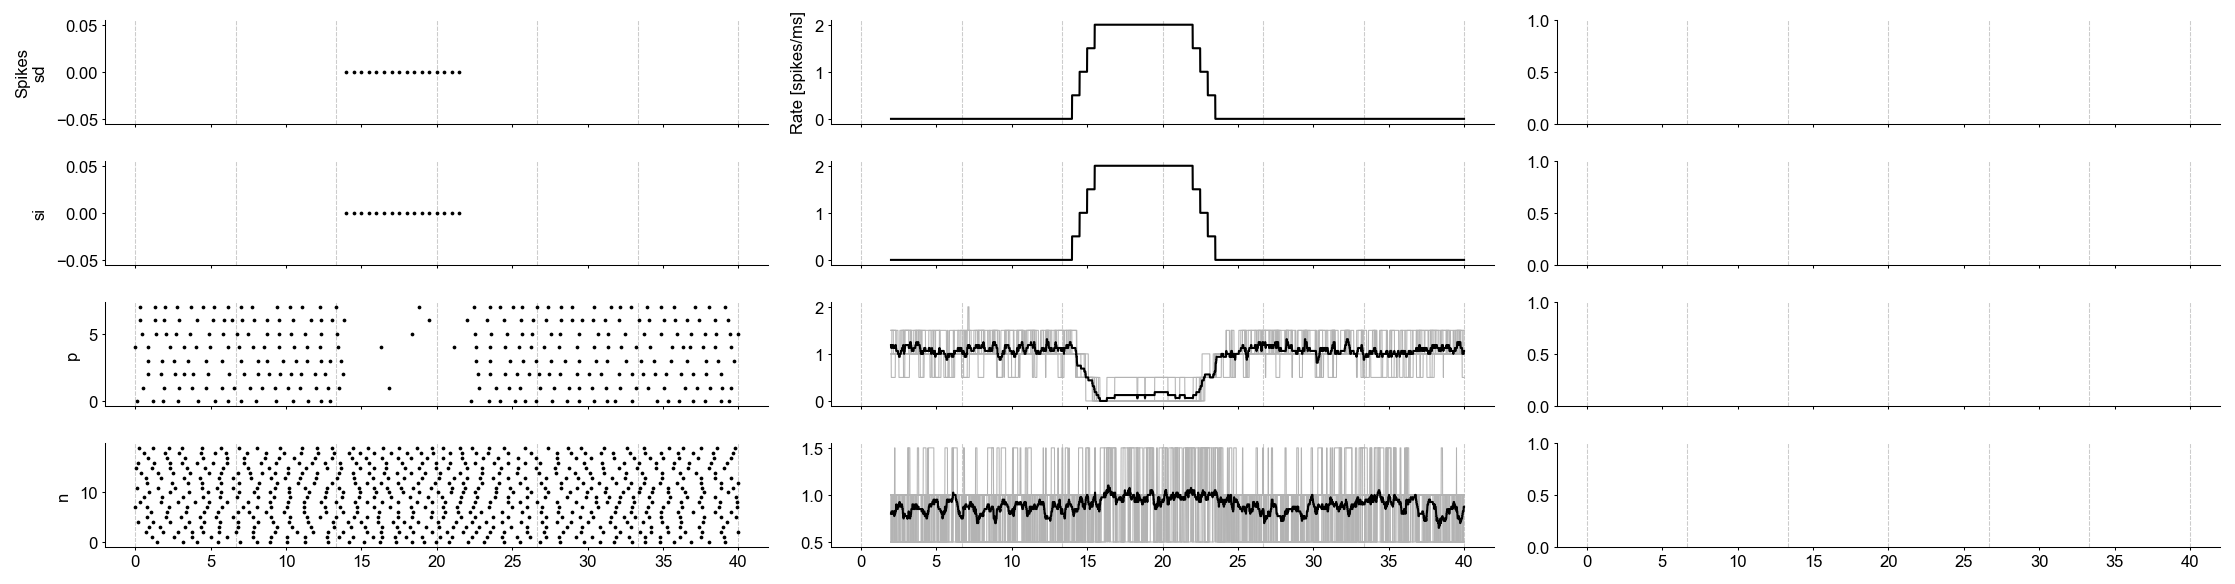

In [773]:
print("Ramping SPNs")
fig, ax = hist.plot_populations(net, dt, syn_colors={'sdn': 'C0', 'sip': 'C3', 'pn': 'C3'}, fig_kws=dict(dpi=150), rate_window=2)
plotter.finalize(fig, None)

In [330]:
# --- Single unit
sd = np.zeros((5000, 1))
si = np.zeros((5000, 1))
sd[2400:3200:50] = 1
si[2400:3200:50] = 1

pops = dict(
    sd=dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    si=dict(N=1, drive=0, threshold=-42, reset=-60, drift=0),
    p=dict(N=1, drive=np.array([2e-2] * 1), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=1, drive=np.array([2.5e-2] * 1), threshold=-42, reset=-60, drift=3e-2),
)
syns = dict(
    sdn=dict(tau=100, peak=np.array([[2e-2]] * 1), sign=-1, source="sd", target="n"),
    sip=dict(tau=100, peak=np.array([[6e-2]] * 1), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[0.7e-2] * 1] * 1), sign=-1, source="p", target="n"),
)
net = SpikingNetwork(pops, syns)
hist = net.simulate(dt, sd=sd, si=si, seed=0)[1000:]

Single unit


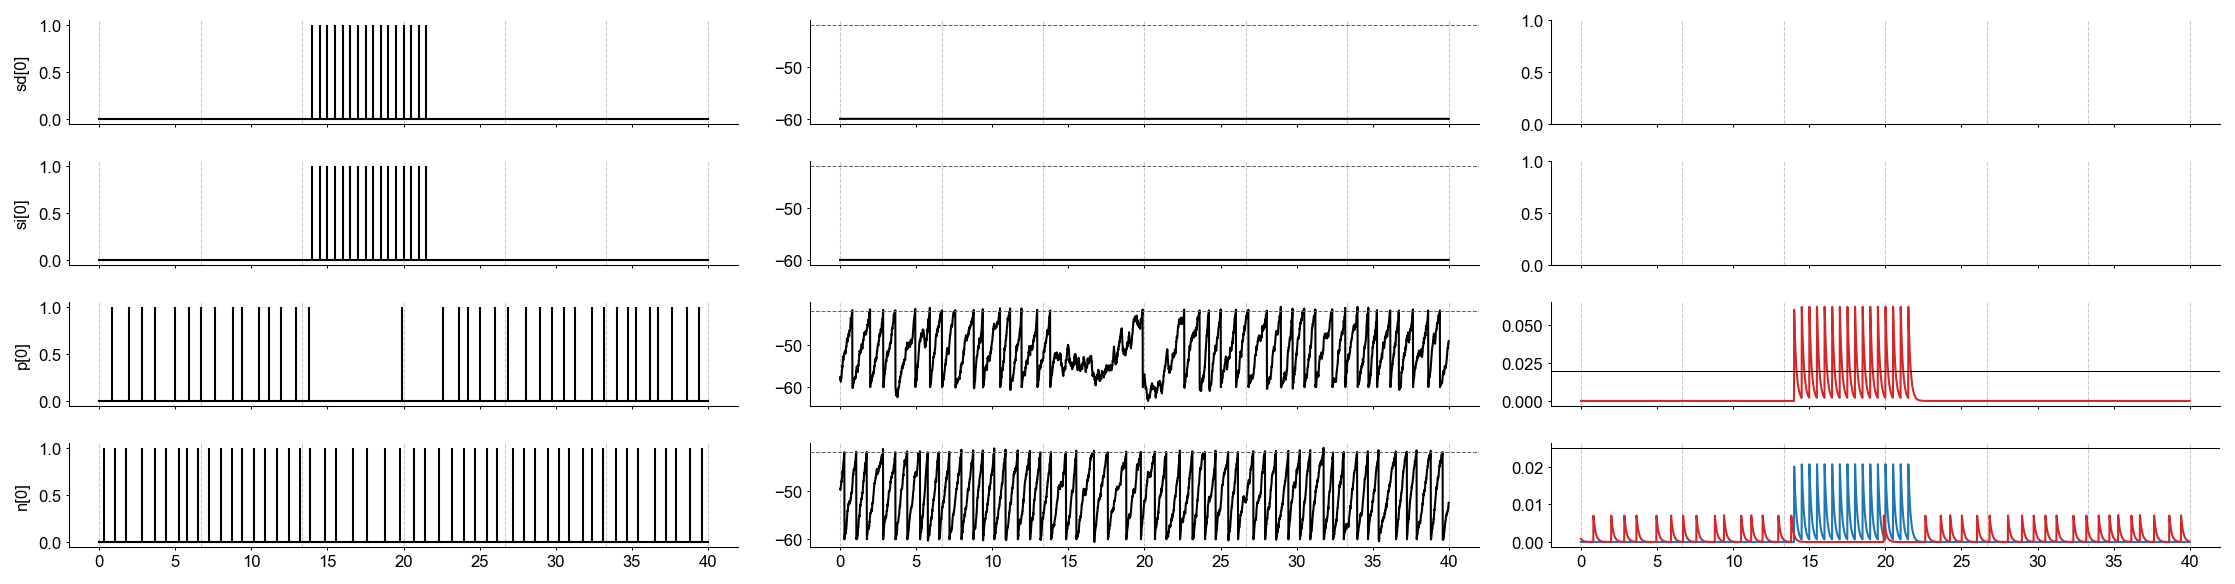

In [331]:
print("Single unit")
fig, ax = hist.plot_units(net, dt, syn_colors={'sdn': 'C0', 'sip': 'C3', 'pn': 'C3'}, fig_kws=dict(dpi=150))
plotter.finalize(fig, None)

In [352]:
def noisy_driven_spikes(tmax, dt, drive_fn, population: Population, seed=0):
    N, reset = population["N"], population["reset"]
    steps = int(tmax / dt)
    V = np.full((steps, N), reset, dtype='float')
    spikes = np.zeros((steps, N))
    rng = np.random.default_rng(seed)
    for step in range(steps - 1):
        step_drive = drive_fn(step * dt / 1000)
        I = step_drive + population['drift'] * rng.normal(size=(N,))
        spikes[step + 1] = V[step] >= population["threshold"]
        V[step + 1] = np.where(
            spikes[step + 1], reset, V[step] + (I * dt)
        )
    return spikes, V


In [775]:
# --- Multiple SPNs
ramping_drive = lambda t: 0 if t < 20 or t > 30 else (0e-2 * (t - 20)/10 + 4e-2)
dt = 10
Ns = 10
Np = 8
Nn = 1

pops = dict(
    sd=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    si=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    p=dict(N=Np, drive=np.array([2e-2] * Np), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=Nn, drive=np.array([2.5e-2] * Nn), threshold=-42, reset=-60, drift=0e-2),
)
syns = dict(
    sdn=dict(tau=50, peak=np.array([[0.7e-2] * Ns] * Nn), sign=-1, source="sd", target="n"),
    sip=dict(tau=300, peak=np.array([[0.2e-2] * Ns] * Np), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[0.8e-2] * Np] * Nn), sign=-1, source="p", target="n"),
)

sd, sd_generated_V = noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 2)
si, si_generated_V = noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 3)

net = SpikingNetwork(pops, syns)
hist = net.simulate(dt, sd=sd, si=si, seed=0)#[1000:]

/Users/kaifox/projects/loop/dynrn/plots/notebook/diffdiff-pft/converging-pop_block-act_raster.pdf


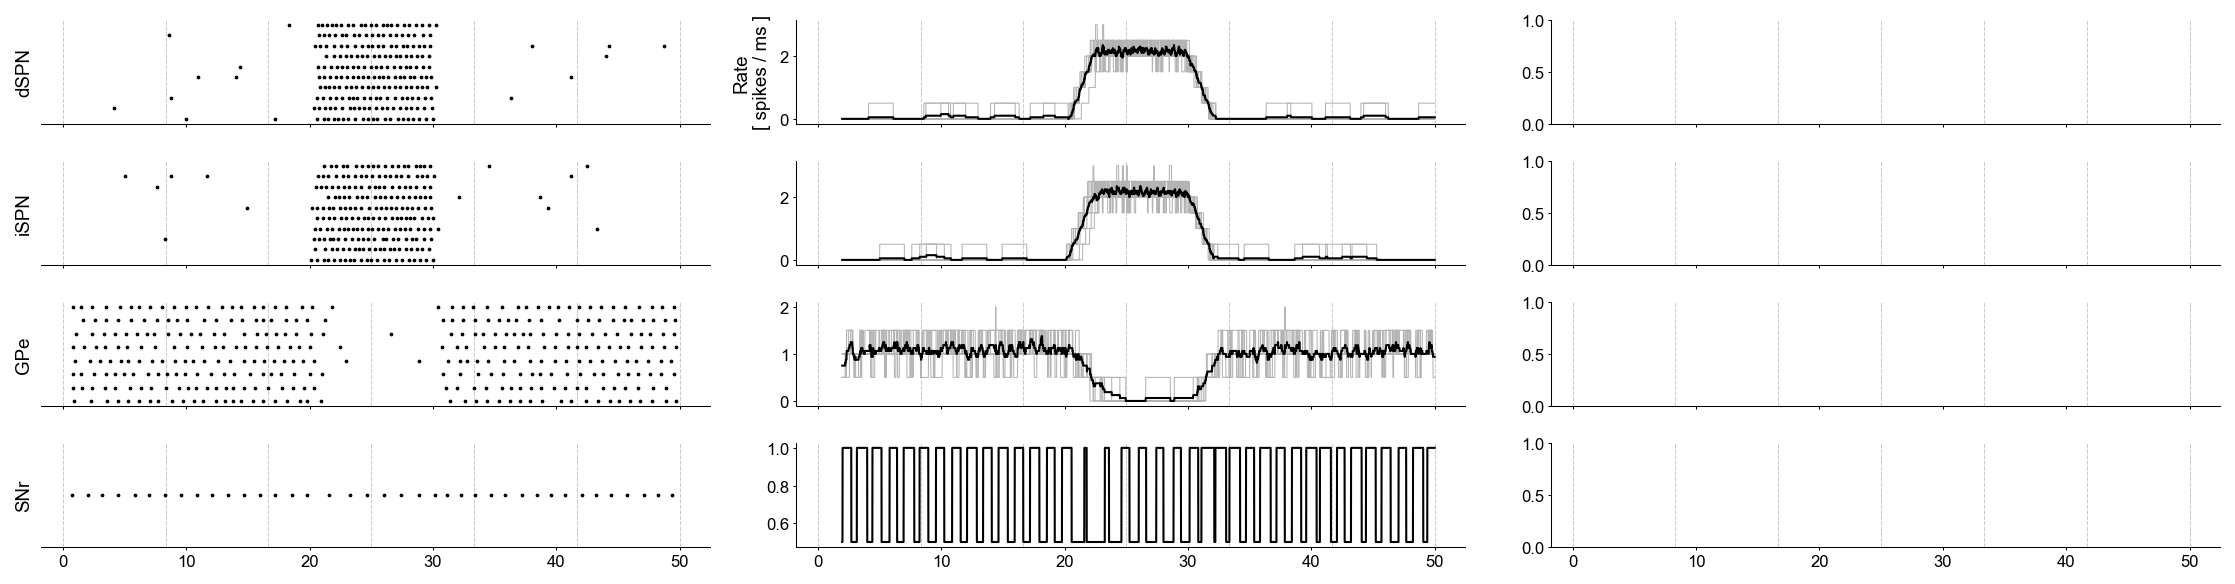

In [789]:
fig, ax = hist.plot_populations(net, dt, syn_colors={'sdn': 'C0', 'sip': 'C3', 'pn': 'C3'}, fig_kws=dict(dpi=150), rate_window=2)
ax[0, 0].set_ylabel("dSPN", fontsize=9)
ax[1, 0].set_ylabel("iSPN", fontsize=9)
ax[2, 0].set_ylabel("GPe", fontsize=9)
ax[3, 0].set_ylabel("SNr", fontsize=9)
ax[0, 1].set_ylabel("Rate\n[ spikes / ms ]", fontsize=9)
for a in ax[:, 0]:
    a.set_yticks([])
    a.spines['left'].set_visible(False)
plotter.finalize(fig, 'converging-pop_block-act_raster', despine=False)

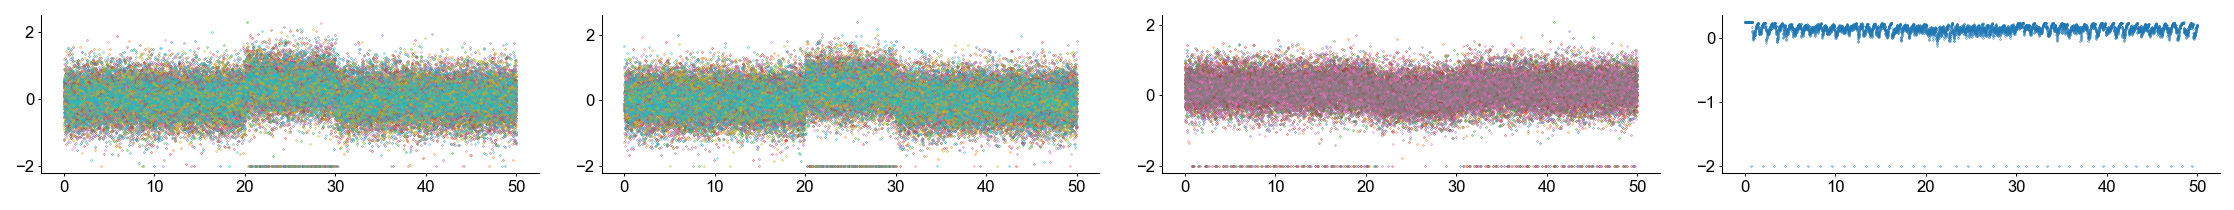

In [577]:
fig, ax = plt.subplots(1, 4, figsize = (15, 1.5), dpi = 150)
x = np.linspace(0, len(hist) * dt / 1000, len(hist))
for arr in np.clip(np.diff(sd_generated_V, axis = 0), -2, None).T:
    ax[0].scatter(x[1:], arr, s = 0.05)
for arr in np.clip(np.diff(si_generated_V, axis = 0), -2, None).T:
    ax[1].scatter(x[1:], arr, s = 0.05)
for arr in np.clip(np.diff(hist['p']['V'], axis = 0), -2, None).T:
    ax[2].scatter(x[1:], arr, s = 0.05)
for arr in np.clip(np.diff(hist['n']['V'], axis = 0), -2, None).T:
    ax[3].scatter(x[1:], arr, s = 0.05)
plotter.finalize(fig, None)

In [596]:
currents = {"d": [], 'i': [], "p": [], "n": []}
pscs = pscs = {"sip": [], "sdn": [], "pn": []}
for i in tqdm.trange(40):
    sd, sd_generated_V = noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 30 + i)
    si, si_generated_V = noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 60 + i)

    net = SpikingNetwork(pops, syns)
    hist = net.simulate(dt, sd=sd, si=si, seed=90+i)[1000:]

    currents["d"].append(np.diff(sd_generated_V[1000:], axis = 0))
    currents["i"].append(np.diff(si_generated_V[1000:], axis = 0))
    currents["p"].append(np.diff(hist['p']["V"], axis = 0))
    currents["n"].append(np.diff(hist['n']["V"], axis = 0))


100%|██████████| 40/40 [00:06<00:00,  5.76it/s]


In [650]:
def _plot_currents(currents, pscs, dt):
    nonspike_currents = {k: np.where(v < -2, np.nan, v) for k, v in currents.items()}

    fig, axes = plt.subplots(2, 4, figsize = (15, 2.5), dpi = 150, sharex=True)
    psc_ax = axes[1]
    ax = axes[0]

    nt = len(next(iter(nonspike_currents.values()))) + 1
    x = np.linspace(0, nt * dt / 1000, nt)
    ax[0].plot(x[1:], np.nanmean(nonspike_currents['sd'], axis = 1), lw = 0.1, color = '.8')
    ax[0].plot(x[1:], np.nanmean(nonspike_currents['sd'], axis = (1, 2)), lw = 0.75, color = '.2')
    ax[1].plot(x[1:], np.nanmean(nonspike_currents['si'], axis = 1), lw = 0.1, color = '.8')
    ax[1].plot(x[1:], np.nanmean(nonspike_currents['si'], axis = (1, 2)), lw = 0.75, color = '.2')
    ax[2].plot(x[1:], np.nanmean(nonspike_currents['p'], axis = 1), lw = 0.1, color = '.8')
    ax[2].plot(x[1:], np.nanmean(nonspike_currents['p'], axis = (1, 2)), lw = 0.75, color = '.2')
    ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = 1), lw = 0.1, color = '.8')
    ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = (1, 2)), lw = 0.75, color = '.2')

    psc_ax[0].set_visible(False)
    psc_ax[1].plot(x, pscs['sip'].mean(axis = 1), color = vu.lighten('C3', 0.5), lw = 0.1)
    psc_ax[1].plot(x, pscs['sip'].mean(axis = (1, 2)), color = 'C3', lw = 1)
    psc_ax[2].plot(x, pscs['pn'].mean(axis = 1), color = vu.lighten('C3', 0.5), lw = 0.1)
    psc_ax[2].plot(x, pscs['pn'].mean(axis = (1, 2)), color = 'C3', lw = 1)
    psc_ax[3].plot(x, pscs['sdn'].mean(axis = 1), color = vu.lighten('C0', 0.5), lw = 0.1)
    psc_ax[3].plot(x, pscs['sdn'].mean(axis = (1, 2)), color = 'C0', lw = 1)


    ax[0].set_title("dSPN", fontdict={'size': 9})
    ax[1].set_title("iSPN", fontdict={'size': 9})
    ax[2].set_title("GPe", fontdict={'size': 9})
    ax[3].set_title("SNr", fontdict={'size': 9})
    ax[0].set_ylabel("Mean current")
    psc_ax[1].set_title(r"iSPN $\rightarrow$ GPe")
    psc_ax[2].set_title(r"GPe $\rightarrow$ SNr")
    psc_ax[3].set_title(r"dSPN $\rightarrow$ SNr")
    psc_ax[1].set_ylabel("PSC")
    psc_ax[1].set_xlabel("Time (ms)")

    return fig, axes


def _multi_history_sim(n_sim: int, network: SpikingNetwork, controls_fn, dt: float, seed: int, warmup = 0):
    currents = {k: [] for k in network.populations}
    pscs = {k: [] for k in network.synapses}
    spikes = {k: [] for k in network.populations}

    for i in tqdm.trange(n_sim):
        controls = controls_fn(seed + i + n_sim)
        control_spikes = {k: v[0] for k, v in controls.items()}
        control_V = {k: v[1] for k, v in controls.items()}

        net = SpikingNetwork(pops, syns)
        hist = net.simulate(dt, **control_spikes, seed=seed+i)[warmup:]

        for (k, pop) in network.populations.items():
            if k in control_V:
                currents[k].append(np.diff(control_V[k][warmup:], axis = 0))
            else:
                currents[k].append(np.diff(hist[k]["V"], axis = 0))
            spikes[k].append(hist[k]['spikes'])
        for (k, syn) in network.synapses.items():
            pscs[k].append(hist[k]['psc'])

    return tuple(
        {k: np.stack(arr, axis = -1) for k, arr in d.items()} 
        for d in (currents, spikes, pscs)
    )

In [790]:

currents, _, pscs = _multi_history_sim(40, SpikingNetwork(pops, syns), lambda seed: {
    'sd': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 1023 + seed),
    'si': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['si'], seed = 3021 + seed),
}, dt, seed=0, warmup = 1000)



100%|██████████| 40/40 [00:07<00:00,  5.69it/s]


/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_34009/4053211681.py:16: RuntimeWarning: Mean of empty slice
  ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = 1), lw = 0.1, color = '.8')


/Users/kaifox/projects/loop/dynrn/plots/notebook/diffdiff-pft/converging-pop_block-act_currents.pdf


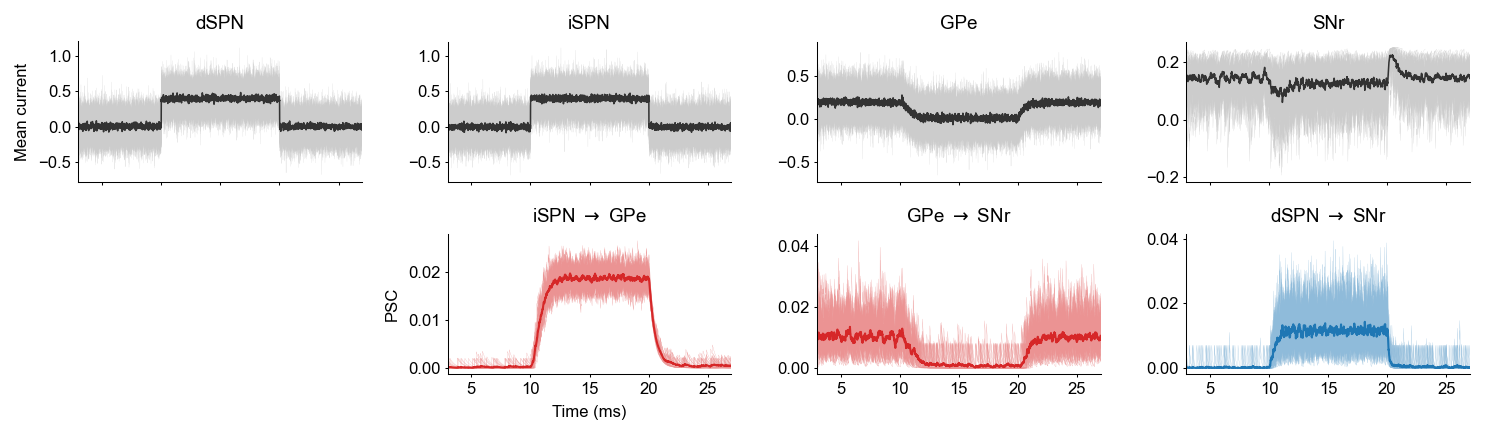

In [792]:
fig, ax = _plot_currents(currents, pscs, dt)
fig.set_size_inches(10, 3)
ax[0, 0].set_xlim(3, 27)
plotter.finalize(fig, 'converging-pop_block-act_currents')

In [582]:
# ---- With more than one SNr unit
# (no difference, since none of the synapse prop's change)

ramping_drive = lambda t: 0 if t < 20 or t > 30 else (0e-2 * (t - 20)/10 + 4e-2)
dt = 10
Ns = 10
Np = 8
Nn = 5

pops = dict(
    sd=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    si=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    p=dict(N=Np, drive=np.array([2e-2] * Np), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=Nn, drive=np.array([2.5e-2] * Nn), threshold=-42, reset=-60, drift=0e-2),
)
syns = dict(
    sdn=dict(tau=50, peak=np.array([[0.7e-2] * Ns] * Nn), sign=-1, source="sd", target="n"),
    sip=dict(tau=300, peak=np.array([[0.2e-2] * Ns] * Np), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[0.8e-2] * Np] * Nn), sign=-1, source="p", target="n"),
)

currents = {"d": [], 'i': [], "p": [], "n": []}
for i in tqdm.trange(40):
    sd, sd_generated_V = noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 30 + i)
    si, si_generated_V = noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 60 + i)

    net = SpikingNetwork(pops, syns)
    hist = net.simulate(dt, sd=sd, si=si, seed=i)[1000:]

    currents["d"].append(np.diff(sd_generated_V[1000:], axis = 0))
    currents["i"].append(np.diff(si_generated_V[1000:], axis = 0))
    currents["p"].append(np.diff(hist['p']["V"], axis = 0))
    currents["n"].append(np.diff(hist['n']["V"], axis = 0))

100%|██████████| 40/40 [00:07<00:00,  5.51it/s]


/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_34009/3411645442.py:12: RuntimeWarning: Mean of empty slice
  ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'][:, [0]], axis = 1), lw = 0.1, color = '.8')



5 SNr units, plotting 1


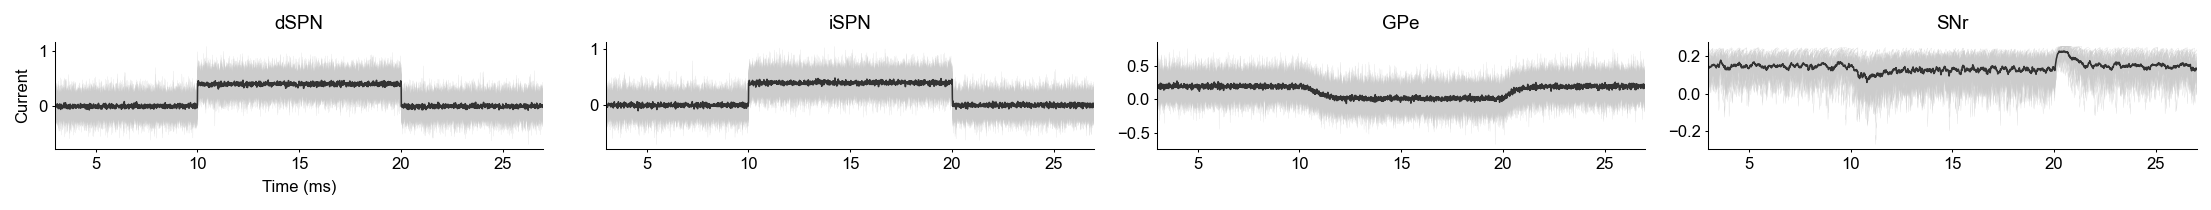

In [593]:
nonspike_currents = {k: np.stack(arr, axis = -1) for k, arr in currents.items()}
nonspike_currents = {k: np.where(v < -2, np.nan, v) for k, v in nonspike_currents.items()}

fig, ax = plt.subplots(1, 4, figsize = (15, 1.5), dpi = 150)
x = np.linspace(0, len(hist) * dt / 1000, len(hist))
ax[0].plot(x[1:], np.nanmean(nonspike_currents['d'], axis = 1), lw = 0.1, color = '.8')
ax[0].plot(x[1:], np.nanmean(nonspike_currents['d'], axis = (1, 2)), lw = 0.75, color = '.2')
ax[1].plot(x[1:], np.nanmean(nonspike_currents['i'], axis = 1), lw = 0.1, color = '.8')
ax[1].plot(x[1:], np.nanmean(nonspike_currents['i'], axis = (1, 2)), lw = 0.75, color = '.2')
ax[2].plot(x[1:], np.nanmean(nonspike_currents['p'], axis = 1), lw = 0.1, color = '.8')
ax[2].plot(x[1:], np.nanmean(nonspike_currents['p'], axis = (1, 2)), lw = 0.75, color = '.2')
ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'][:, [0]], axis = 1), lw = 0.1, color = '.8')
ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'][:, [0]], axis = (1, 2)), lw = 0.75, color = '.2')

ax[0].set_title("dSPN", fontdict={'size': 9})
ax[1].set_title("iSPN", fontdict={'size': 9})
ax[2].set_title("GPe", fontdict={'size': 9})
ax[3].set_title("SNr", fontdict={'size': 9})
ax[0].set_ylabel("Current")
ax[0].set_xlabel("Time (ms)")

for a in ax:
    a.set_xlim(3, 27)

print(f"\n{Nn} SNr units, plotting 1")
plotter.finalize(fig, None)

/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_34009/1853046975.py:12: RuntimeWarning: Mean of empty slice
  ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = 1), lw = 0.1, color = '.8')



5 SNr units, plotting all


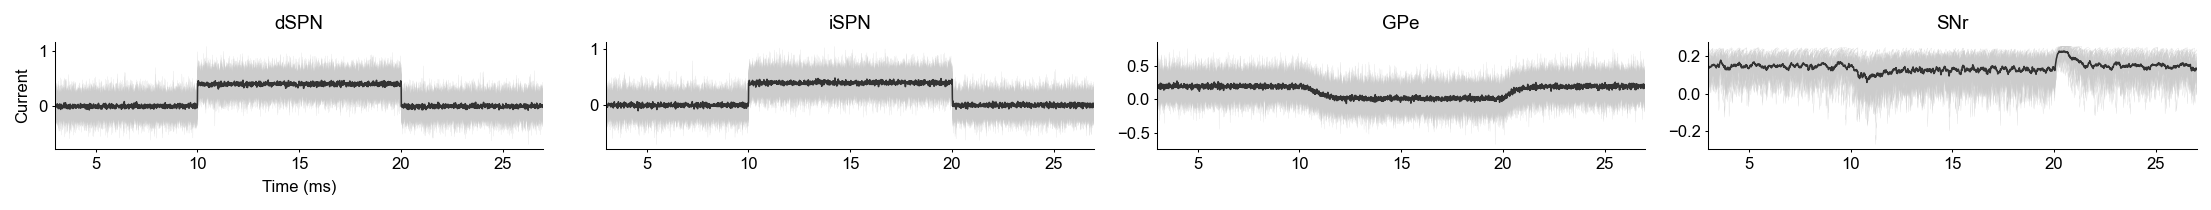

In [594]:
# plot all `Nn` SNr units
nonspike_currents = {k: np.stack(arr, axis = -1) for k, arr in currents.items()}
nonspike_currents = {k: np.where(v < -2, np.nan, v) for k, v in nonspike_currents.items()}

fig, ax = plt.subplots(1, 4, figsize = (15, 1.5), dpi = 150)
x = np.linspace(0, len(hist) * dt / 1000, len(hist))
ax[0].plot(x[1:], np.nanmean(nonspike_currents['d'], axis = 1), lw = 0.1, color = '.8')
ax[0].plot(x[1:], np.nanmean(nonspike_currents['d'], axis = (1, 2)), lw = 0.75, color = '.2')
ax[1].plot(x[1:], np.nanmean(nonspike_currents['i'], axis = 1), lw = 0.1, color = '.8')
ax[1].plot(x[1:], np.nanmean(nonspike_currents['i'], axis = (1, 2)), lw = 0.75, color = '.2')
ax[2].plot(x[1:], np.nanmean(nonspike_currents['p'], axis = 1), lw = 0.1, color = '.8')
ax[2].plot(x[1:], np.nanmean(nonspike_currents['p'], axis = (1, 2)), lw = 0.75, color = '.2')
ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = 1), lw = 0.1, color = '.8')
ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = (1, 2)), lw = 0.75, color = '.2')

ax[0].set_title("dSPN", fontdict={'size': 9})
ax[1].set_title("iSPN", fontdict={'size': 9})
ax[2].set_title("GPe", fontdict={'size': 9})
ax[3].set_title("SNr", fontdict={'size': 9})
ax[0].set_ylabel("Current")
ax[0].set_xlabel("Time (ms)")

for a in ax:
    a.set_xlim(3, 27)

print(f"\n{Nn} SNr units, plotting all")
plotter.finalize(fig, None)

100%|██████████| 40/40 [00:07<00:00,  5.68it/s]
/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_34009/4053211681.py:16: RuntimeWarning: Mean of empty slice
  ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = 1), lw = 0.1, color = '.8')



1 Ramping SPN signal


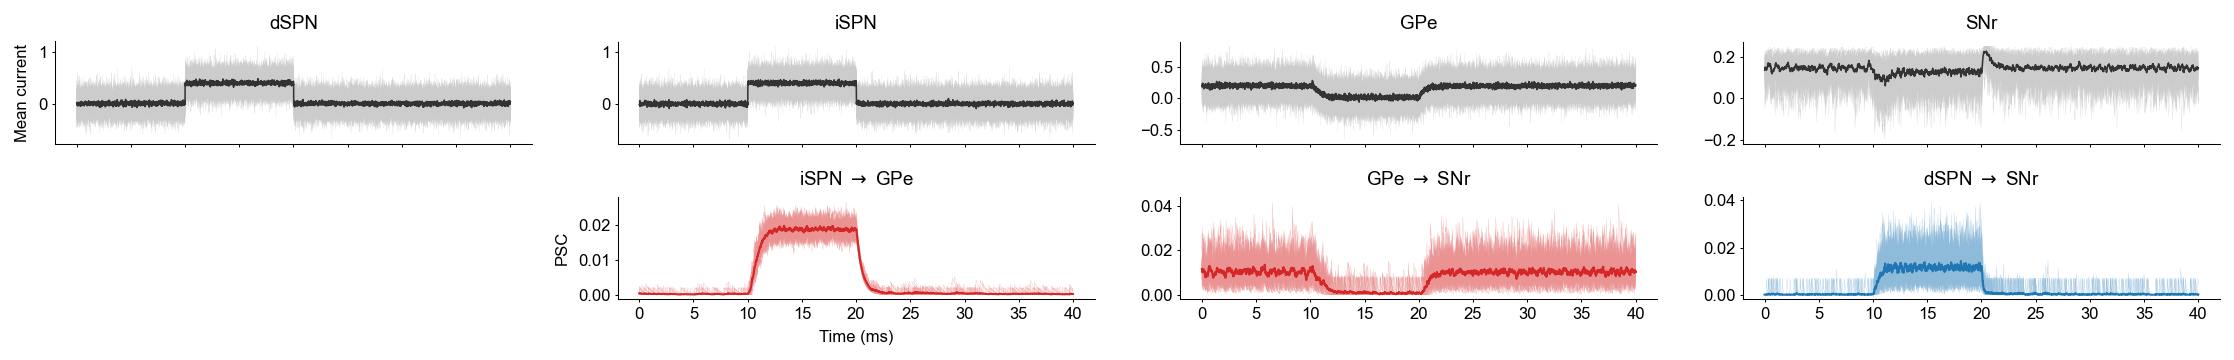

In [654]:
# --- Ramping SPN signal
ramping_drive = lambda t: 0 if t < 20 or t > 30 else (0e-2 * (t - 20)/10 + 4e-2)
dt = 10
Ns = 10
Np = 8
Nn = 1

pops = dict(
    sd=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    si=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    p=dict(N=Np, drive=np.array([2e-2] * Np), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=Nn, drive=np.array([2.5e-2] * Nn), threshold=-42, reset=-60, drift=0e-2),
)
syns = dict(
    sdn=dict(tau=50, peak=np.array([[0.7e-2] * Ns] * Nn), sign=-1, source="sd", target="n"),
    sip=dict(tau=300, peak=np.array([[0.2e-2] * Ns] * Np), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[0.8e-2] * Np] * Nn), sign=-1, source="p", target="n"),
)

currents, _, pscs = _multi_history_sim(40, SpikingNetwork(pops, syns), lambda seed: {
    'sd': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 1023 + seed),
    'si': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['si'], seed = 3021 + seed),
}, dt, seed=0, warmup = 1000)

print(f"\n{Nn} Ramping SPN signal")
fig, ax = _plot_currents(currents, pscs, dt)
plotter.finalize(fig, None)


In [703]:
# --- Ramping SPN signal

ramping_drive = lambda t: 0 if t < 20 or t > 30 else (4e-2 * (t - 20)/10 + 0e-2)
dt = 10
Ns = 10
Np = 8
Nn = 1

pops = dict(
    sd=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    si=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    p=dict(N=Np, drive=np.array([2e-2] * Np), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=Nn, drive=np.array([2.5e-2] * Nn), threshold=-42, reset=-60, drift=0e-2),
)
syns = dict(
    sdn=dict(tau=50, peak=np.array([[0.7e-2] * Ns] * Nn), sign=-1, source="sd", target="n"),
    sip=dict(tau=300, peak=np.array([[0.2e-2] * Ns] * Np), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[0.8e-2] * Np] * Nn), sign=-1, source="p", target="n"),
)

currents, _, pscs = _multi_history_sim(40, SpikingNetwork(pops, syns), lambda seed: {
    'sd': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 1023 + seed),
    'si': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['si'], seed = 3021 + seed),
}, dt, seed=0, warmup = 1000)


100%|██████████| 40/40 [00:07<00:00,  5.54it/s]


/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_34009/4053211681.py:16: RuntimeWarning: Mean of empty slice
  ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = 1), lw = 0.1, color = '.8')



1 Ramping SPN signal


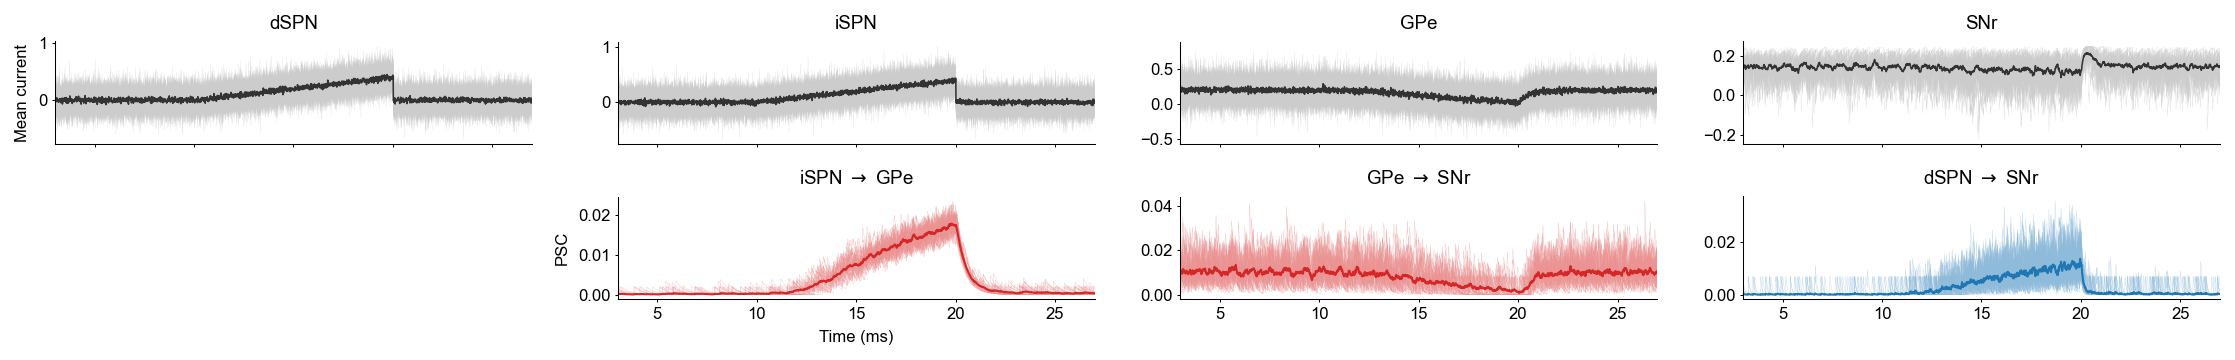

In [704]:
print(f"\n{Nn} Ramping SPN signal")
fig, ax = _plot_currents(currents, pscs, dt)
ax[0, 0].set_xlim(3, 27)
plotter.finalize(fig, None)

In [699]:
# --- Ramping SPN signal

ramping_drive = lambda t: 0 if t < 20 or t > 30 else (4e-2 * (t - 20)/10 + 0e-2)
dt = 10
Ns = 10
Np = 8
Nn = 1

pops = dict(
    sd=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    si=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    p=dict(N=Np, drive=np.array([2e-2] * Np), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=Nn, drive=np.array([2.5e-2] * Nn), threshold=-42, reset=-60, drift=0e-2),
)
syns = dict(
    sdn=dict(tau=100, peak=np.array([[0.4e-2] * Ns] * Nn), sign=-1, source="sd", target="n"),
    sip=dict(tau=100, peak=np.array([[0.4e-2] * Ns] * Np), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[1.2e-2] * Np] * Nn), sign=-1, source="p", target="n"),
)

currents, _, pscs = _multi_history_sim(80, SpikingNetwork(pops, syns), lambda seed: {
    'sd': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 1023 + seed),
    'si': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['si'], seed = 3021 + seed),
}, dt, seed=0, warmup = 1000)


100%|██████████| 80/80 [00:14<00:00,  5.62it/s]



1 Ramping SPN signal


/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_34009/4053211681.py:16: RuntimeWarning: Mean of empty slice
  ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = 1), lw = 0.1, color = '.8')


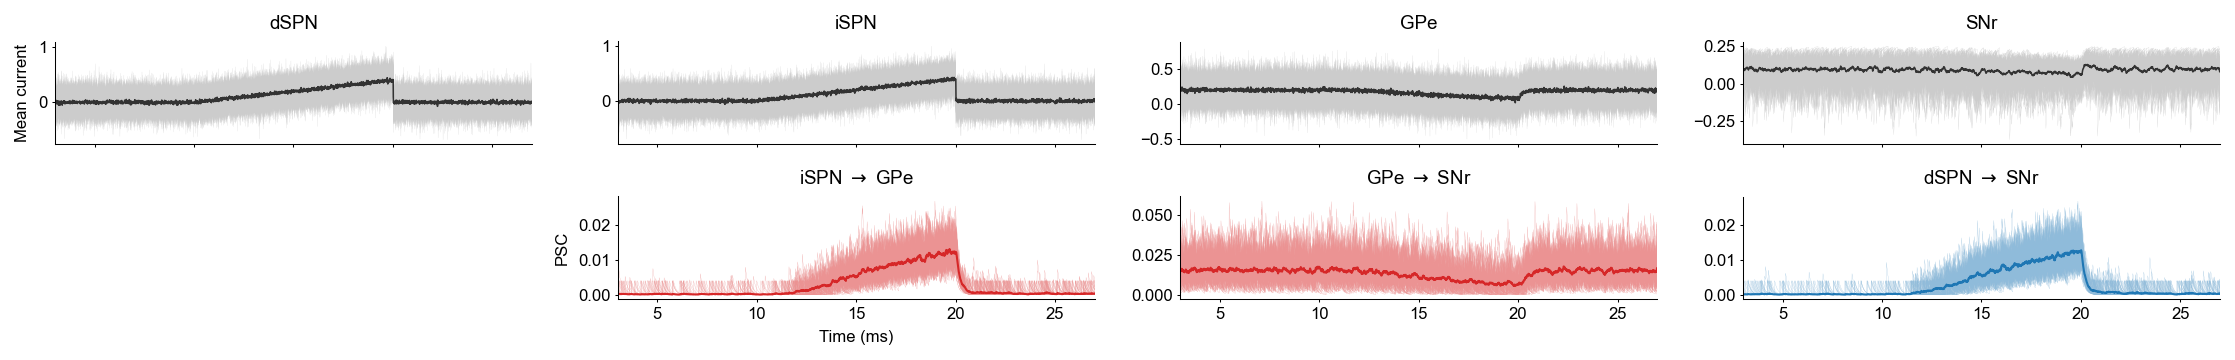

In [700]:
print(f"\n{Nn} Ramping SPN signal")
fig, ax = _plot_currents(currents, pscs, dt)
ax[0, 0].set_xlim(3, 27)
plotter.finalize(fig, None)

In [793]:
# --- Rect SPN signal, no tau difference

ramping_drive = lambda t: 0 if t < 20 or t > 30 else (0e-2 * (t - 20)/10 + 4e-2)
dt = 10
Ns = 10
Np = 8
Nn = 1

pops = dict(
    sd=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    si=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=5e-2),
    p=dict(N=Np, drive=np.array([2e-2] * Np), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=Nn, drive=np.array([2.5e-2] * Nn), threshold=-42, reset=-60, drift=0e-2),
)
syns = dict(
    sdn=dict(tau=100, peak=np.array([[0.4e-2] * Ns] * Nn), sign=-1, source="sd", target="n"),
    sip=dict(tau=100, peak=np.array([[0.4e-2] * Ns] * Np), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[1.2e-2] * Np] * Nn), sign=-1, source="p", target="n"),
)

currents, _, pscs = _multi_history_sim(80, SpikingNetwork(pops, syns), lambda seed: {
    'sd': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['sd'], seed = 1023 + seed),
    'si': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['si'], seed = 3021 + seed),
}, dt, seed=0, warmup = 1000)


100%|██████████| 80/80 [00:14<00:00,  5.64it/s]



Rect SPN signal, no tau difference


/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_34009/4053211681.py:16: RuntimeWarning: Mean of empty slice
  ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = 1), lw = 0.1, color = '.8')


/Users/kaifox/projects/loop/dynrn/plots/notebook/diffdiff-pft/conv-pop_block-act_no-tau_currents.pdf


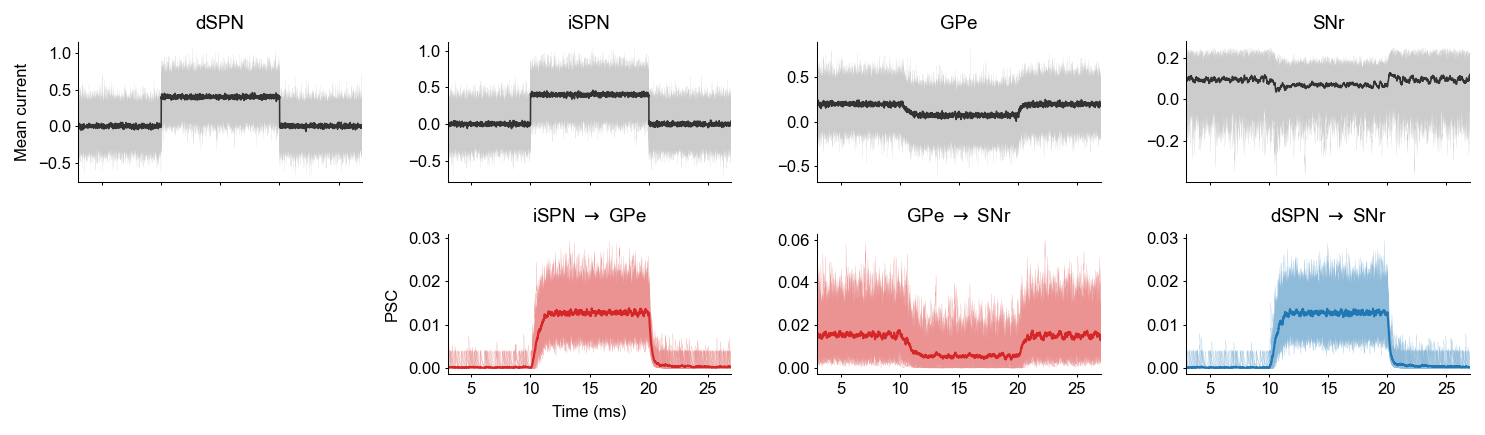

In [794]:
print(f"\nRect SPN signal, no tau difference")
fig, ax = _plot_currents(currents, pscs, dt)
fig.set_size_inches(10, 3)
ax[0, 0].set_xlim(3, 27)
plotter.finalize(fig, 'conv-pop_block-act_no-tau_currents')

### Modeling by differentially timed exponentials

/Users/kaifox/projects/loop/dynrn/plots/notebook/diffdiff-pft/filter-difference.pdf


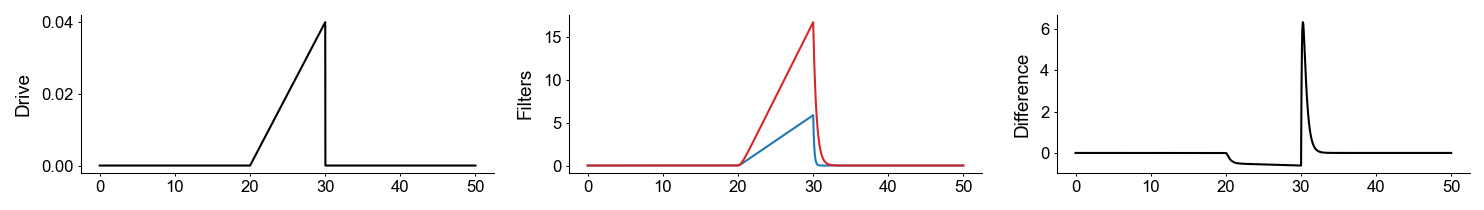

In [797]:
def exp_diff_drive(tmax, dt, drive_fn, tau_short, tau_long):
    nt = int(tmax / dt)
    drive = np.full(nt, drive_fn(0), dtype='float')
    fast = np.full((nt,), drive_fn(0), dtype='float')
    slow = np.full((nt,), drive_fn(0), dtype='float')
    fast_decay = np.exp(-np.log(2) / (tau_short / dt))
    slow_decay = np.exp(-np.log(2) / (tau_long / dt))
    for step in range(nt - 1):
        drive[step + 1] = drive_fn((step + 1) * dt / 1000)
        fast[step + 1] = fast_decay * fast[step] + drive[step] * dt
        slow[step + 1] = slow_decay * slow[step] + drive[step] * dt
    return drive, fast, slow


ramping_drive = lambda t: 0 if t < 20 or t > 30 else (4e-2 * (t - 20)/10 + 0e-2)
dt = 10
drive, fast, slow = exp_diff_drive(50 * 1000, dt, ramping_drive, 100, 300)

fig, ax = plt.subplots(1, 3, figsize = (10, 1.5), dpi=150)
nt = len(drive)
x = np.linspace(0, nt * dt / 1000, nt)
ax[0].plot(x, drive, 'k-', lw = 1)
ax[1].plot(x, fast, 'C0-', lw = 1)
ax[1].plot(x, slow, 'C3-', lw = 1)
ax[2].plot(x, slow - 2.95 * fast, 'k-', lw = 1)
ax[0].set_ylabel("Drive", fontsize=9)
ax[1].set_ylabel("Filters", fontsize=9)
ax[2].set_ylabel("Difference", fontsize=9)
plotter.finalize(fig, 'filter-difference', transparent=True)

### PF pathway

In [756]:
# --- Multiple SPNs
ramping_drive = lambda t: 0 if t < 20 or t > 30 else (0e-2 * (t - 20)/10 + 4e-2)
dt = 10
Nx, Ns, Np, Nn, Npf = 1, 10, 8, 5, 1

pops = dict(
    x=dict(N=Nx, drive=0, threshold=-42, reset=-60, drift=3e-2),
    sd=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=3e-2),
    si=dict(N=Ns, drive=0, threshold=-42, reset=-60, drift=3e-2),
    p=dict(N=Np, drive=np.array([2e-2] * Np), threshold=-42, reset=-60, drift=4e-2),
    n=dict(N=Nn, drive=np.array([2.5e-2] * Nn), threshold=-42, reset=-60, drift=3e-2),
    pf=dict(N=Nn, drive=np.array([2e-2] * Nn), threshold=-42, reset=-60, drift=2e-2)
)
syns = dict(
    xsd=dict(tau=100, peak=np.array([[1e-1] * Nx] * Ns), sign=1, source="x", target="sd"),
    xsi=dict(tau=100, peak=np.array([[1e-1] * Nx] * Ns), sign=1, source="x", target="si"),
    sdn=dict(tau=50, peak=np.array([[0.9e-2] * Ns] * Nn), sign=-1, source="sd", target="n"),
    sip=dict(tau=400, peak=np.array([[0.2e-2] * Ns] * Np), sign=-1, source="si", target="p"),
    pn=dict(tau=100, peak=np.array([[1.1e-2] * Np] * Nn), sign=-1, source="p", target="n"),
    npf=dict(tau=100, peak=np.array([[2e-2] * Nn] * Npf), sign=-1, source="n", target="pf")
)

spikes_x, x_generated_V = noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['x'], seed = 2)

net = SpikingNetwork(pops, syns)
hist = net.simulate(dt, x=spikes_x, seed=0)

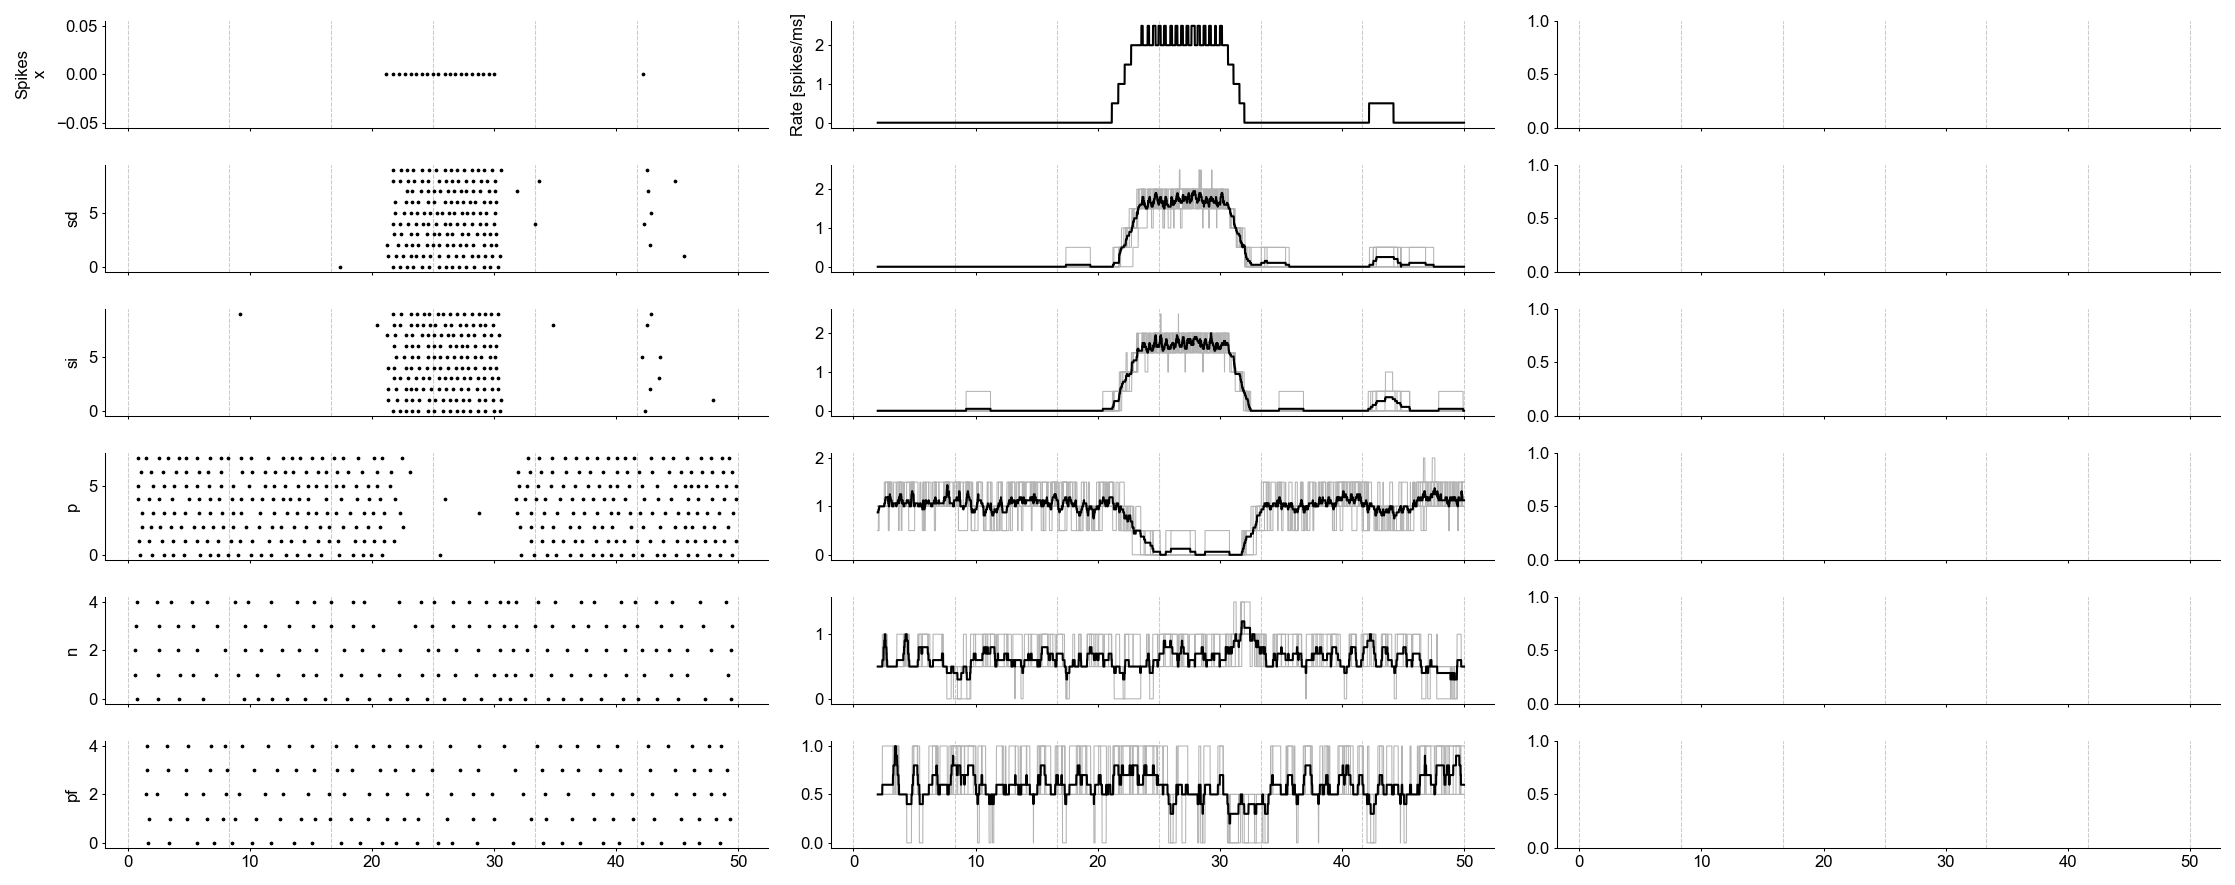

In [757]:
fig, ax = hist.plot_populations(net, dt, syn_colors={'sdn': 'C0', 'sip': 'C3', 'pn': 'C3'}, fig_kws=dict(dpi=150), rate_window=2)
plotter.finalize(fig, None)

In [758]:
def _plot_currents_pf(currents, pscs, dt):
    nonspike_currents = {k: np.where(v < -2, np.nan, v) for k, v in currents.items()}

    fig, axes = plt.subplots(2, 5, figsize = (15, 2.5), dpi = 150, sharex=True)
    psc_ax = axes[1]
    ax = axes[0]

    nt = len(next(iter(nonspike_currents.values()))) + 1
    x = np.linspace(0, nt * dt / 1000, nt)
    ax[0].plot(x[1:], np.nanmean(nonspike_currents['sd'], axis = 1), lw = 0.1, color = '.8')
    ax[0].plot(x[1:], np.nanmean(nonspike_currents['sd'], axis = (1, 2)), lw = 0.75, color = '.2')
    ax[1].plot(x[1:], np.nanmean(nonspike_currents['si'], axis = 1), lw = 0.1, color = '.8')
    ax[1].plot(x[1:], np.nanmean(nonspike_currents['si'], axis = (1, 2)), lw = 0.75, color = '.2')
    ax[2].plot(x[1:], np.nanmean(nonspike_currents['p'], axis = 1), lw = 0.1, color = '.8')
    ax[2].plot(x[1:], np.nanmean(nonspike_currents['p'], axis = (1, 2)), lw = 0.75, color = '.2')
    ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = 1), lw = 0.1, color = '.8')
    ax[3].plot(x[1:], np.nanmean(nonspike_currents['n'], axis = (1, 2)), lw = 0.75, color = '.2')
    ax[4].plot(x[1:], np.nanmean(nonspike_currents['pf'], axis = 1), lw = 0.1, color = '.8')
    ax[4].plot(x[1:], np.nanmean(nonspike_currents['pf'], axis = (1, 2)), lw = 0.75, color = '.2')

    psc_ax[0].set_visible(False)
    psc_ax[1].plot(x, pscs['sip'].mean(axis = 1), color = vu.lighten('C3', 0.5), lw = 0.1)
    psc_ax[1].plot(x, pscs['sip'].mean(axis = (1, 2)), color = 'C3', lw = 1)
    psc_ax[2].plot(x, pscs['pn'].mean(axis = 1), color = vu.lighten('C3', 0.5), lw = 0.1)
    psc_ax[2].plot(x, pscs['pn'].mean(axis = (1, 2)), color = 'C3', lw = 1)
    psc_ax[3].plot(x, pscs['sdn'].mean(axis = 1), color = vu.lighten('C0', 0.5), lw = 0.1)
    psc_ax[3].plot(x, pscs['sdn'].mean(axis = (1, 2)), color = 'C0', lw = 1)
    psc_ax[4].plot(x, pscs['npf'].mean(axis = 1), color = vu.lighten('C4', 0.5), lw = 0.1)
    psc_ax[4].plot(x, pscs['npf'].mean(axis = (1, 2)), color = 'C4', lw = 1)


    ax[0].set_title("dSPN", fontdict={'size': 9})
    ax[1].set_title("iSPN", fontdict={'size': 9})
    ax[2].set_title("GPe", fontdict={'size': 9})
    ax[3].set_title("SNr", fontdict={'size': 9})
    ax[4].set_title("PF", fontdict={'size': 9})
    ax[0].set_ylabel("Mean current")
    psc_ax[1].set_title(r"iSPN $\rightarrow$ GPe")
    psc_ax[2].set_title(r"GPe $\rightarrow$ SNr")
    psc_ax[3].set_title(r"dSPN $\rightarrow$ SNr")
    psc_ax[4].set_title(r"SNr $\rightarrow$ PF")
    psc_ax[1].set_ylabel("PSC")
    psc_ax[1].set_xlabel("Time (ms)")

    return fig, axes

100%|██████████| 40/40 [00:13<00:00,  3.02it/s]



Introduce PF pathway


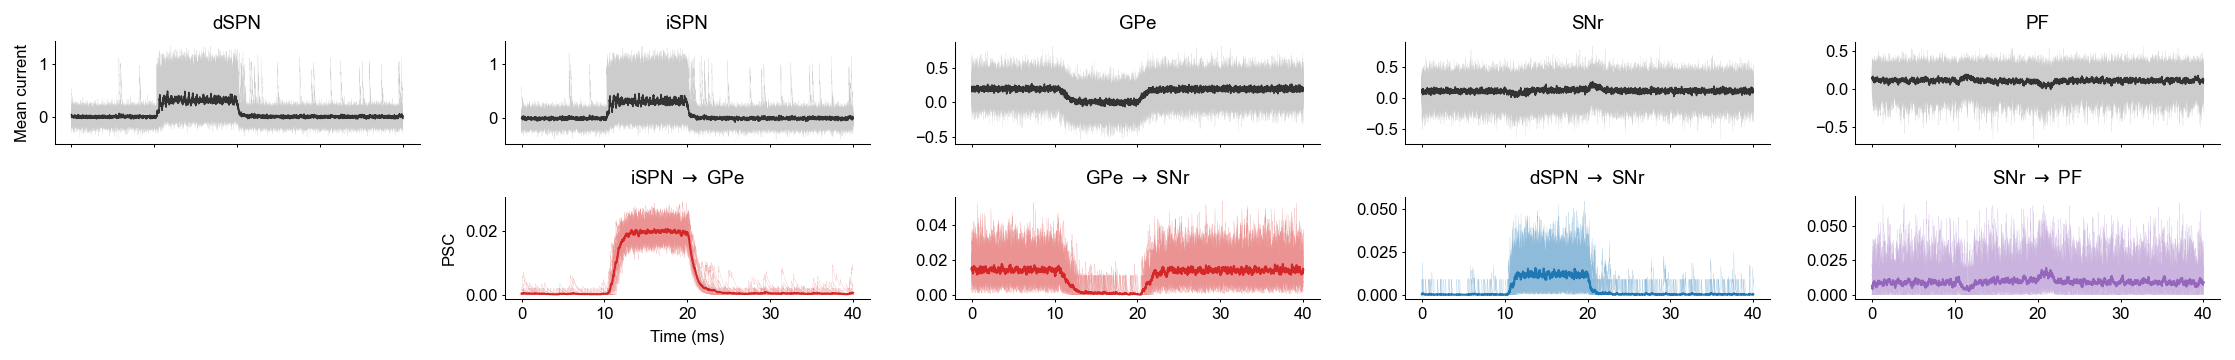

In [759]:
currents, _, pscs = _multi_history_sim(40, SpikingNetwork(pops, syns), lambda seed: {
    'x': noisy_driven_spikes(50 * 1000, dt, ramping_drive, pops['x'], seed = 1323 + seed),
}, dt, seed=0, warmup = 1000)

print(f"\nIntroduce PF pathway")
fig, ax = _plot_currents_pf(currents, pscs, dt)
# ax[0, 0].set_xlim(3, 27)
plotter.finalize(fig, None)

In [9]:
import torch as th
ln = th.nn.LayerNorm(100, elementwise_affine=False)
ln.eval()
x0 = th.randn(1, 100)
x1 = 2 * x0
y0 = ln(x0)
y1 = ln(x1)

In [10]:
print("y0", y0.mean(), y0.std())
print("y1", y1.mean(), y1.std())

y0 tensor(-1.9073e-08) tensor(1.0050)
y1 tensor(-1.4305e-08) tensor(1.0050)
